# Cryptocurrency Trading Strategies: Funding-Rate Signal & On-Chain Value/Trend

## Team Information

- Dong Yan | `12498145`
- Malank Goel | `12350684`
- Garrett White | `12363929`
- Claire Kim | `12328448`

## 1) Abstract

We develop and evaluate two distinct quantitative trading strategies in the cryptocurrency market, each exploiting a different information source:

**Strategy A — Funding-Rate Signal (Spot Directional).** Perpetual-swap funding rates, paid every eight hours on Binance, encode directional crowding information that predicts near-term spot returns. We construct four funding-rate-derived signals — momentum, z-score reversion, regime quantile, and cross-coin dispersion — and combine them into a composite spot-trading portfolio weighted 70 % BTC, 20 % ETH, and 10 % XRP with signal-level improvements (regime filter, spot-momentum filter).

**Strategy B — On-Chain Value / Trend.** Daily on-chain metrics from CoinMetrics (active addresses, transaction counts, NVT ratio, fee revenue) are combined with a multi-timeframe trend-following base (MA-50/100/200 blend). A consensus "guard" signal reduces exposure only when multiple on-chain indicators jointly signal overheating, preserving trend-following alpha while limiting drawdowns.

The two strategies are combined into a single portfolio using (i) equal-weight (50/50) and (ii) inverse-volatility (risk-parity) allocation. A leverage overlay targets 18 % annualised volatility with drawdown-aware de-risking. All results are reported under both zero-cost and realistic-cost (10 bps transaction cost + funding spread) assumptions across eight cryptocurrencies over the period January 2023 – February 2026.

## 2) Keywords

Cryptocurrency, Funding-Rate Signal, Funding Rate, Perpetual Swap, On-Chain Analytics, Trend Following, Signal Guard, Risk Parity, Volatility Targeting, Portfolio Construction

## 3) Introduction & Literature Review

### Motivation

Cryptocurrency markets exhibit several features that create opportunities for systematic strategies. Perpetual-swap funding rates create a measurable carry premium that reflects directional crowding (Schmeling, Schrimpf, & Todorov, 2025). Meanwhile, on-chain data — transaction volumes, active addresses, and network valuation ratios — provide a fundamentals-based view of network health that is unique to crypto assets and unavailable in traditional markets (Cong, Karolyi, Tang, & Zhao, 2025).

Our project exploits both information sources in a two-strategy framework. The first strategy uses funding rates as predictive signals for spot-market directional positioning — rather than running a traditional delta-neutral carry trade, we treat the funding rate as a signal for spot returns. The second strategy combines on-chain fundamental indicators with trend-following to build an adaptive long-only allocation.

### Literature Context

**Carry and Funding Signals in crypto markets.** Carry strategies are well-established in FX and fixed income (Koijen et al., 2018). In crypto, the perpetual-swap funding mechanism creates an analogous carry opportunity. When funding rates are persistently positive, longs pay shorts — this crowding signal has been shown to predict mean-reverting spot returns at short horizons. Schmeling, Schrimpf, and Todorov (2025) provide a comprehensive analysis of crypto carry dynamics using data from Binance, OKEx, CME, and other exchanges for BTC and ETH futures (March 2019–July 2024). They document that the futures-spot basis can reach exceptionally high levels — sometimes exceeding 40% per annum — with an average of approximately 7% p.a., roughly 10× larger than S&P 500 carry. They trace these elevated and volatile spreads to the interplay of two forces: (i) demand from smaller, trend-chasing investors seeking leveraged long exposure, evidenced by Google search volume for "bitcoin futures" strongly predicting carry levels (R² ≈ 12%), and (ii) limited deployment of arbitrage capital due to regulatory and margin frictions — on CME, for instance, spot crypto positions cannot be used as collateral for short futures, forcing arbitrageurs to pledge capital twice. A key causal finding is that the introduction of spot BTC ETFs in January 2024, which eased institutional access to spot holdings, compressed carry by 36–97% on CME. This is reflected acutely in our sub-technical notebook on the Carry and Funding Signals strategies. Although the paper focuses on fixed-maturity futures, its structural explanations extend directly to perpetual-swap funding rates: the same demand imbalance and arbitrage constraints that inflate the futures basis also keep perpetual funding rates persistently positive, which forms the theoretical foundation for our Strategy A.

**On-chain analytics as fundamental signals.** Blockchain-native data such as transaction counts, active addresses, and network valuations contain information about future returns beyond what is captured by price-based signals. Cong, Karolyi, Tang, and Zhao (2025) formalise this intuition by constructing an Active-Addresses-to-Market-Cap (AA/MC) ratio — analogous to the book-to-market ratio in equity pricing — and demonstrating a significant crypto value effect. Using 679 cryptocurrencies over July 2017–September 2024 at weekly frequency, they show that portfolios sorted on AA/MC generate excess returns of 2.4% per week (equal-weighted, t = 3.77) and 1.3% per week (value-weighted, t = 2.48). They propose a four-factor "C-4" model (Market, Size, Momentum, and the new AA/MC-based Value factor), which outperforms the earlier three-factor model of Liu, Tsyvinski, and Wu (2022) in explaining the cross-section of crypto returns: the value factor alone contributes the largest marginal improvement to the model's squared Sharpe ratio. Crucially, they trace the value premium to compensation for on-chain activity risk — measured by average block time — rather than general liquidity risk, confirming that network-level usage metrics capture fundamental risk premia unique to crypto assets. Their finding that on-chain activity ratios carry systematic pricing information directly motivates our use of active addresses, transaction counts, NVT, and fee metrics as signals in Strategy B.

**Crypto risk premia and network factors.** Liu and Tsyvinski (2021) provide the first comprehensive empirical asset-pricing study of cryptocurrencies, analysing 1,707 coins over January 2011–December 2018. Their central finding is that cryptocurrency returns are driven by crypto-specific network factors rather than production-side factors. Active-address growth alone explains 30% of the variation in coin market returns (coefficient = 1.86, t = 5.34), while composite network growth (wallet users, active addresses, transaction counts, payment counts) yields R² = 19%. In stark contrast, none of the eight electricity-cost proxies or six computing-cost proxies they construct show significant explanatory power — the marginal cost of mining does not drive valuations. On predictability, they document strong time-series momentum: top-tercile past-return portfolios earn 8.01% per week versus 1.10% for the bottom tercile (t = 4.30 for the spread), with effects persisting 1–8 weeks and surviving out-of-sample tests. Investor attention (Google/Twitter search volume) independently predicts returns — a one-standard-deviation attention increase forecasts a 3–5% weekly return increase — and operates as a distinct mechanism from momentum. Notably, they find that crypto valuation ratios (user-to-market-cap, address-to-market-cap) do **not** predict returns in their sample, a gap later addressed by Cong et al. (2025) with the AA/MC factor on a larger and more recent dataset. These results inform our strategy design in two ways: (i) the strong momentum effect justifies our trend-following base in Strategy B, and (ii) the primacy of network adoption metrics over production costs validates our choice of on-chain activity signals over mining-related indicators.

**Trend following.** Time-series momentum has been extensively documented across asset classes (Moskowitz, Ooi, & Pedersen, 2012). In crypto markets, where regime shifts are pronounced and momentum effects are particularly strong — Liu and Tsyvinski (2021) report out-of-sample top-minus-bottom momentum spreads of 5.62% per week — trend-following serves as a natural base allocation that can be overlaid with contrarian on-chain signals. Our Strategy B adopts this architecture: a multi-timeframe MA blend (50/100/200-day) captures the persistent trending behaviour, while on-chain signals serve only as a consensus guard against overheating, consistent with the finding that contrarian signals alone destroy alpha by fighting strong trends.

## 4) Data

### Data Sources

| Source | Frequency | Fields | Usage |
|--------|-----------|--------|-------|
| **Binance Spot/Perp OHLCV** | 1h, 4h, 1d | Open, High, Low, Close, Volume, Trades, Buy/Sell Ratio | Price data for all strategies |
| **Binance Perpetual Funding Rates** | 8-hourly | Funding rate, funding time | Strategy A signal construction |
| **CoinMetrics On-Chain** | Daily | AdrActCnt, TxCnt, CapMrktCurUSD, FeeTotNtv, HashRate | Strategy B fundamental signals |

> **Note on Funding Rate Data:** Binance perpetual funding rate data is not accessible from the United States due to geo-restrictions on the Binance international platform. We fetched this data using a VPN connection to access the Binance API from a non US IP address. All funding rate CSVs were downloaded once and stored locally for reproducibility.

### Asset Universe

Eight cryptocurrencies: **BTC, ETH, ADA, DOGE, LINK, LTC, UNI, XRP**

- Date range: **2023-01-01 to 2026-02-26** (~3.2 years)
- This universe spans large-cap (BTC, ETH), mid-cap (LINK, LTC, UNI), and small-cap (ADA, DOGE, XRP) assets, providing cross-sectional diversity.

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="An input array is constant")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 25)

# ── Shared Constants ──
TC = 0.001                          # 10 bps round-trip per unit turnover
HOURS_PER_YEAR = 365.25 * 24
START_DATE = pd.Timestamp("2023-01-01")

# FR signal-specific
CARRY_WINDOW_SHORT = 24
CARRY_WINDOW_MED   = 72
CARRY_WINDOW_LONG  = 168
ZSCORE_WINDOW      = 168
FUNDING_PERIODS_PER_DAY = 3

# On-chain-specific
WINDOW, MIN_PERIODS = 30, 20
IC_WINDOW = 60
WF_MIN_HISTORY = 120
COINS     = ["btc", "eth", "ada", "doge", "link", "ltc", "uni", "xrp"]
POW_COINS = {"btc", "ltc", "doge"}
PRICE_COLS = ["date", "open", "high", "low", "close", "volume", "return_1d"]

V2_SIGNALS = [
    "z_NVTC", "z_fee_per_tx", "z_FeeTotUSD_proxy", "z_AdrActCnt", "z_TxCnt",
    "z_buy_pressure", "z_vol_ratio", "z_mom_5d",
]
V3_SIGNALS_RAW = [
    "z_NVTC_tanh", "z_fee_per_tx_tanh", "z_FeeTotUSD_proxy_tanh",
    "z_AdrActCnt_tanh", "z_TxCnt_tanh",
    "z_buy_pressure_tanh", "z_vol_ratio_tanh", "z_mom_5d_tanh",
    "z_mom_composite", "z_adr_momentum", "z_bb_pctB",
    "z_intraday_vol", "z_vol_skew",
]

# ── Data Paths ──
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data_fetch" / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find data_fetch/data")

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data_fetch" / "data"
FUNDING_ROOT = DATA_ROOT / "fundrate"

price_coin_dirs = {p.name for p in DATA_ROOT.iterdir() if p.is_dir() and p.name != "fundrate"}
funding_coin_dirs = {p.name for p in FUNDING_ROOT.iterdir()
                     if p.is_dir() and (p / "funding_rate.csv").exists()}
CARRY_COINS = sorted(price_coin_dirs & funding_coin_dirs)
FUNDING_FILES = {coin: FUNDING_ROOT / coin / "funding_rate.csv" for coin in CARRY_COINS}

print(f"Project root : {PROJECT_ROOT}")
print(f"Carry coins  : {CARRY_COINS}")
print(f"On-chain root: {DATA_ROOT}")

Project root : /Users/vera/Downloads/QTS_Project
Carry coins  : ['ada', 'btc', 'doge', 'eth', 'link', 'ltc', 'uni', 'xrp']
On-chain root: /Users/vera/Downloads/QTS_Project/data_fetch/data


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — FR SIGNAL STRATEGY (hourly klines + funding rates)
# ══════════════════════════════════════════════════════════════════════════════

def load_funding(coin: str) -> pd.DataFrame:
    path = FUNDING_FILES[coin]
    df = pd.read_csv(path)
    df["fundingTime"] = pd.to_datetime(df["fundingTime"])
    df = df.rename(columns={"fundingRate": "funding_rate"})
    df = df.sort_values("fundingTime").reset_index(drop=True)
    df = df[df["fundingTime"] >= START_DATE].copy()
    df["coin"] = coin
    return df[["fundingTime", "funding_rate", "coin"]].copy()


def load_klines_1h(coin: str) -> pd.DataFrame:
    path = DATA_ROOT / coin / "1h" / "binance_klines.csv"
    df = pd.read_csv(path, parse_dates=["date"])
    if "open_time" not in df.columns:
        df["open_time"] = df["date"]
    else:
        df["open_time"] = pd.to_datetime(df["open_time"])
    df = df.sort_values("open_time").reset_index(drop=True)
    df = df[df["open_time"] >= START_DATE].copy()
    df["coin"] = coin
    df["return_1h"] = df["close"].pct_change()
    return df


def merge_funding_and_klines(coin: str) -> pd.DataFrame:
    klines = load_klines_1h(coin)
    funding = load_funding(coin)
    merged = pd.merge_asof(
        klines.sort_values("open_time"),
        funding[["fundingTime", "funding_rate"]].sort_values("fundingTime"),
        left_on="open_time", right_on="fundingTime", direction="backward",
    )
    merged["funding_rate"] = merged["funding_rate"].fillna(0.0)
    merged["funding_rate_1h"] = merged["funding_rate"] / 8.0
    merged["coin"] = coin
    return merged.reset_index(drop=True)


# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — ON-CHAIN STRATEGY (daily klines + CoinMetrics + 4h features)
# ══════════════════════════════════════════════════════════════════════════════

def load_coin(coin: str) -> pd.DataFrame:
    base = os.path.join(str(DATA_ROOT), coin, "1d")
    oc = pd.read_csv(os.path.join(base, "coinmetrics_onchain.csv"), parse_dates=["time"])
    oc["date"] = oc["time"].dt.tz_convert(None).dt.normalize()
    base_cols = ["date", "AdrActCnt", "TxCnt", "CapMrktCurUSD", "tx_per_active_addr"]
    if "FeeTotNtv" in oc.columns:
        base_cols.append("FeeTotNtv")
    else:
        oc["FeeTotNtv"] = np.nan
    if coin in POW_COINS and "HashRate" in oc.columns:
        base_cols.append("HashRate")
    else:
        oc["HashRate"] = np.nan
    extra = [c for c in ["HashRate", "FeeTotNtv"] if c not in base_cols]
    oc = oc[base_cols + extra].copy()
    kl = pd.read_csv(os.path.join(base, "binance_klines.csv"), parse_dates=["date"])
    kl = kl[PRICE_COLS].copy()
    df = pd.merge(kl, oc, on="date", how="inner")
    df["coin"] = coin
    return df.sort_values("date").reset_index(drop=True)


def load_4h_features(coin: str) -> pd.DataFrame:
    path = os.path.join(str(DATA_ROOT), coin, "4h", "binance_klines.csv")
    if not os.path.exists(path):
        return pd.DataFrame()
    kl4 = pd.read_csv(path, parse_dates=["date"])
    kl4["date_day"] = kl4["date"].dt.normalize()
    kl4["ret_4h"] = kl4["close"].pct_change()
    agg_dict = {"ret_4h": [("intraday_vol", "std"), ("max_4h_ret", lambda x: x.abs().max())]}
    for col_name in ["high_low_spread", "number_of_trades", "volume", "buy_sell_ratio"]:
        if col_name in kl4.columns:
            if col_name == "high_low_spread":
                agg_dict[col_name] = [("intraday_range", "mean")]
            elif col_name == "volume":
                agg_dict[col_name] = [("vol_skew", "skew")]
            elif col_name == "buy_sell_ratio":
                agg_dict[col_name] = [("buy_ratio_mean", "mean")]
    daily_agg = kl4.groupby("date_day").agg(
        intraday_vol=("ret_4h", "std"),
        max_4h_ret=("ret_4h", lambda x: x.abs().max()),
    ).reset_index()
    if "high_low_spread" in kl4.columns:
        daily_agg["intraday_range"] = kl4.groupby("date_day")["high_low_spread"].mean().values
    if "volume" in kl4.columns:
        vs = kl4.groupby("date_day")["volume"].apply(lambda x: x.skew())
        daily_agg["vol_skew"] = vs.values
    if "buy_sell_ratio" in kl4.columns:
        daily_agg["buy_ratio_mean"] = kl4.groupby("date_day")["buy_sell_ratio"].mean().values
    daily_agg.rename(columns={"date_day": "date"}, inplace=True)
    return daily_agg

print("Data loading functions ready.")

Data loading functions ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════

# ── FR signal data (hourly) ──
coin_data = {}
for coin in CARRY_COINS:
    try:
        coin_data[coin] = merge_funding_and_klines(coin)
        n = len(coin_data[coin])
        rng = f"{coin_data[coin]['open_time'].min()} → {coin_data[coin]['open_time'].max()}"
        print(f"  {coin.upper():5s}: {n:>6,} hourly rows  |  {rng}")
    except Exception as e:
        print(f"  {coin.upper():5s}: FAILED — {e}")

print(f"\nLoaded {len(coin_data)} coin(s) for FR signal strategy.\n")

# ── On-chain data (daily) ──
coin_daily = {}
for coin in COINS:
    try:
        coin_daily[coin] = load_coin(coin)
        n = len(coin_daily[coin])
        rng = f"{coin_daily[coin]['date'].min().date()} → {coin_daily[coin]['date'].max().date()}"
        print(f"  {coin.upper():5s}: {n:>5,} daily rows  |  {rng}")
    except Exception as e:
        print(f"  {coin.upper():5s}: FAILED — {e}")

print(f"\nLoaded {len(coin_daily)} coin(s) for on-chain strategy.")

  ADA  : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  BTC  : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  DOGE : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  ETH  : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  LINK : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  LTC  : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  UNI  : 27,642 hourly rows  |  2023-01-01 00:00:00 → 2026-02-26 00:00:00
  XRP  : 22,980 hourly rows  |  2023-07-14 13:00:00 → 2026-02-26 00:00:00

Loaded 8 coin(s) for FR signal strategy.

  BTC  : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  ETH  : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  ADA  : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  DOGE : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  LINK : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  LTC  : 1,153 daily rows  |  2023-01-01 → 2026-02-26
  UNI  : 1,153 daily rows  |  2023-01-01 

In [ ]:
# ── Data Summary Statistics ──
summary_rows = []
for coin in sorted(set(list(coin_data.keys()) + list(coin_daily.keys()))):
    row = {"Coin": coin.upper()}
    if coin in coin_daily:
        d = coin_daily[coin]
        row["Daily Rows"] = len(d)
        row["Start"] = str(d["date"].min().date())
        row["End"] = str(d["date"].max().date())
        row["Avg Close"] = d["close"].mean()
        row["Avg Daily Vol"] = d["return_1d"].std()
        row["Has On-Chain"] = "AdrActCnt" in d.columns and d["AdrActCnt"].notna().any()
    if coin in coin_data:
        row["Hourly Rows"] = len(coin_data[coin])
        row["Avg Funding Rate"] = coin_data[coin]["funding_rate"].mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("=" * 80)
print("  DATA SUMMARY")
print("=" * 80)
display(summary_df)

  DATA SUMMARY


,Coin,Daily Rows,Start,End,Avg Close,Avg Daily Vol,Has On-Chain,Hourly Rows,Avg Funding Rate
0,ADA,1153,2023-01-01,2026-02-26,0.5191,0.0472,True,27642,0.0001
1,BTC,1153,2023-01-01,2026-02-26,66243.0714,0.0248,True,27642,0.0001
2,DOGE,1153,2023-01-01,2026-02-26,0.1477,0.0462,True,27642,0.0001
3,ETH,1153,2023-01-01,2026-02-26,2633.9445,0.0337,True,27642,0.0001
4,LINK,1153,2023-01-01,2026-02-26,13.4711,0.0448,True,27642,0.0001
5,LTC,1153,2023-01-01,2026-02-26,85.3845,0.0386,True,27642,0.0001
6,UNI,1153,2023-01-01,2026-02-26,7.3230,0.0536,True,27642,0.0001
7,XRP,959,2023-07-14,2026-02-26,1.4393,0.0419,True,22980,0.0001


**Table Interpretation.** The data summary confirms coverage across 8 coins from early 2023 to February 2026, providing ~3 years of daily observations per asset. Average daily volatility varies significantly across coins — large-caps (BTC, ETH) exhibit lower volatility than altcoins (DOGE, XRP), which motivates the risk-parity weighting in the combined portfolio. The average funding rate is positive for most coins, reflecting the persistent long-bias in crypto perpetual markets documented by Schmeling et al. (2025).

## 5) Strategy A: Funding-Rate Signal for Spot Trading

### Quantitative Rationale

Binance perpetual swaps charge a funding rate every 8 hours to anchor the perpetual price to spot. When the rate is **positive**, longs pay shorts, indicating bullish crowding; when **negative**, shorts pay longs. This funding rate encodes information about market positioning that has predictive power for short-term spot returns.

Rather than running a traditional delta-neutral carry trade (which has shown declining alpha post-2024), we use the funding rate as a **directional signal for spot trading**. Four distinct signals are constructed:

1. **Funding Momentum** — EWM difference of the 24h funding rate; captures directional shifts in crowding.
2. **Z-Score Reversion** — 72h rolling z-score of funding rate; positions against extremes (mean reversion).
3. **Regime Quantile** — positions based on funding rate quintile rank (80th → short, 20th → long).
4. **Cross-Coin Dispersion** — cross-sectional rank of each coin's funding rate; overweight underfunded, underweight overfunded.

Each signal intitially generates a position in $\{-1, 0, +1\}$ that is applied to spot returns with T+1 execution.

### Signal-Level Improvements

Two filters are applied to raw positions:
- **Regime filter**: reduces position by 70% when funding-rate volatility is below its expanding median (no opportunity periods).
- **Spot momentum filter**: reduces position by 80% when it contradicts strong recent spot momentum (72h sum exceeding 1.5σ).

### Composite Construction

The final portfolio allocates:
- **70% BTC**: ZScore (60%) + Regime (20%) + Dispersion (20%)
- **20% ETH**: Dispersion (100%)
- **10% XRP**: ZScore (75%) + Dispersion (25%)

This signal allocation reflects heuristically an informed combination of each coin's best-performing signal combinations. The coin weight of .7, .2, .1, respectively, was chosen to mimic mimic both intuitive exposure to crypto markets and performance over training period. Again, this was done heurtically to avoid overfitting and emphasize intuitive contructs of the strategy.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STRATEGY A — SIGNAL CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

def build_carry_signals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["carry_1h"] = df["funding_rate_1h"]
    for window, label in [
        (CARRY_WINDOW_SHORT, "carry_roll_1d"),
        (CARRY_WINDOW_MED,   "carry_roll_3d"),
        (CARRY_WINDOW_LONG,  "carry_roll_7d"),
    ]:
        df[label] = df["carry_1h"].rolling(window, min_periods=window // 2).mean()
    df["carry_ann"] = df["carry_roll_3d"] * HOURS_PER_YEAR
    roll_mean = df["carry_1h"].rolling(ZSCORE_WINDOW, min_periods=ZSCORE_WINDOW // 2).mean()
    roll_std = df["carry_1h"].rolling(ZSCORE_WINDOW, min_periods=ZSCORE_WINDOW // 2).std()
    floor = roll_std.median() * 0.01
    if pd.isna(floor) or floor <= 0:
        floor = 1e-10
    df["carry_zscore"] = (df["carry_1h"] - roll_mean) / roll_std.clip(lower=floor)
    df["carry_cumulative"] = df["carry_1h"].cumsum()
    regime_signal = df["carry_roll_3d"]
    df["carry_regime"] = "neutral"
    df.loc[regime_signal > 1e-6, "carry_regime"] = "positive"
    df.loc[regime_signal < -1e-6, "carry_regime"] = "negative"
    df["vol_1d"] = df["return_1h"].rolling(24, min_periods=12).std()
    df["vol_7d"] = df["return_1h"].rolling(168, min_periods=84).std()
    df["vol_ann"] = df["vol_7d"] * np.sqrt(HOURS_PER_YEAR)
    return df


def compute_metrics(ret_series, periods_per_year=365*24):
    r = ret_series.dropna()
    if len(r) == 0:
        return None
    mean = r.mean()
    vol = r.std()
    sharpe = np.sqrt(periods_per_year) * mean / vol if vol > 0 else np.nan
    downside = r[r < 0].std()
    sortino = np.sqrt(periods_per_year) * mean / downside if downside > 0 else np.nan
    equity = (1 + r).cumprod()
    total_return = equity.iloc[-1] - 1
    years = len(r) / periods_per_year
    cagr = (equity.iloc[-1])**(1/years) - 1 if years > 0 else np.nan
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan
    return {"Total Return": round(total_return, 4), "CAGR": round(cagr, 4),
            "Volatility": round(vol * np.sqrt(periods_per_year), 4),
            "Sharpe": round(sharpe, 4), "Sortino": round(sortino, 4),
            "Max Drawdown": round(max_dd, 4), "Calmar": round(calmar, 4)}

# Build signals
for coin in coin_data:
    coin_data[coin] = build_carry_signals(coin_data[coin])

print("Funding-rate signals constructed for all coins.")

Funding-rate signals constructed for all coins.


In [ ]:
# ── Spot Strategy 1: Funding Momentum ──
mom_results = {}
for coin, df in coin_data.items():
    temp = df.copy()
    temp["fr_mom"] = temp["funding_rate"].ewm(span=24).mean().diff()
    temp["pos_mom"] = np.sign(temp["fr_mom"])
    temp["spot_ret"] = temp["close"].pct_change()
    temp["ret_mom"] = temp["pos_mom"].shift(1) * temp["spot_ret"]
    temp["cum_mom"] = (1 + temp["ret_mom"].fillna(0)).cumprod()
    mom_results[coin] = temp

# ── Spot Strategy 2: Funding Z-Score Reversion ──
zf_results = {}
for coin, df in coin_data.items():
    temp = df.copy()
    mean = temp["funding_rate"].rolling(72).mean()
    std = temp["funding_rate"].rolling(72).std()
    temp["fr_z"] = (temp["funding_rate"] - mean) / std
    temp["pos_z"] = -np.sign(temp["fr_z"])
    temp["spot_ret"] = temp["close"].pct_change()
    temp["ret_z"] = temp["pos_z"].shift(1) * temp["spot_ret"]
    temp["cum_z"] = (1 + temp["ret_z"].fillna(0)).cumprod()
    zf_results[coin] = temp

# ── Spot Strategy 3: Funding Regime Quantile ──
regime_results = {}
for coin, df in coin_data.items():
    temp = df.copy()
    q_low = temp["funding_rate"].rolling(120).quantile(0.2)
    q_high = temp["funding_rate"].rolling(120).quantile(0.8)
    pos = np.zeros(len(temp))
    pos[temp["funding_rate"] > q_high] = -1
    pos[temp["funding_rate"] < q_low] = 1
    temp["pos_regime"] = pos
    temp["spot_ret"] = temp["close"].pct_change()
    temp["ret_regime"] = temp["pos_regime"].shift(1) * temp["spot_ret"]
    temp["cum_regime"] = (1 + temp["ret_regime"].fillna(0)).cumprod()
    regime_results[coin] = temp

# ── Spot Strategy 4: Cross-Coin Funding Dispersion ──
disp_results = {}
fund_panel = pd.concat(
    {coin: df.set_index("open_time")["funding_rate"] for coin, df in coin_data.items()},
    axis=1,
)
fund_rank = fund_panel.rank(axis=1, pct=True)
for coin, df in coin_data.items():
    temp = df.copy().set_index("open_time")
    temp["rank"] = fund_rank[coin]
    pos = np.zeros(len(temp))
    pos[temp["rank"] > 0.8] = -1
    pos[temp["rank"] < 0.2] = 1
    temp["pos_disp"] = pos
    temp["spot_ret"] = temp["close"].pct_change()
    temp["ret_disp"] = temp["pos_disp"].shift(1) * temp["spot_ret"]
    temp["cum_disp"] = (1 + temp["ret_disp"].fillna(0)).cumprod()
    disp_results[coin] = temp.reset_index()

# ── Per-coin metrics ──
strategies = {
    "Momentum": (mom_results, "ret_mom"),
    "ZScore_Reversion": (zf_results, "ret_z"),
    "Regime": (regime_results, "ret_regime"),
    "Dispersion": (disp_results, "ret_disp"),
}
pos_col_map = {"Momentum": "pos_mom", "ZScore_Reversion": "pos_z",
               "Regime": "pos_regime", "Dispersion": "pos_disp"}
rows = []
for strat_name, (results, col) in strategies.items():
    for coin, df in results.items():
        metrics = compute_metrics(df[col])
        if metrics:
            row = {"Coin": coin.upper(), "Strategy": strat_name}
            row.update(metrics)
            rows.append(row)

metrics_table = pd.DataFrame(rows)
metrics_table_sorted = metrics_table.sort_values(["Coin", "Strategy"]).reset_index(drop=True)

print("=" * 80)
print("  SPOT STRATEGY METRICS (All Coins × All Signals)")
print("=" * 80)
display(metrics_table_sorted)

  SPOT STRATEGY METRICS (All Coins × All Signals)


,Coin,Strategy,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
0,ADA,Dispersion,-0.5815,-0.2412,0.5352,-0.2361,-0.1558,-0.8072,-0.2988
1,ADA,Momentum,-0.8504,-0.4524,0.8806,-0.2475,-0.3362,-0.9131,-0.4954
2,ADA,Regime,-0.2096,-0.0718,0.4763,0.0829,0.0523,-0.7196,-0.0998
3,ADA,ZScore_Reversion,-0.3287,-0.1376,0.9047,0.2969,0.3654,-0.9051,-0.1520
4,BTC,Dispersion,0.4680,0.1294,0.2596,0.5982,0.4283,-0.2436,0.5311
5,BTC,Momentum,-0.8915,-0.5053,0.4658,-1.2776,-1.5838,-0.8930,-0.5658
6,BTC,Regime,0.8193,0.2088,0.2753,0.8262,0.6597,-0.3129,0.6676
7,BTC,ZScore_Reversion,2.3438,0.5457,0.4723,1.1580,1.5391,-0.3662,1.4901
8,DOGE,Dispersion,-0.6239,-0.2665,0.4985,-0.3732,-0.2604,-0.8136,-0.3275
9,DOGE,Momentum,-0.8984,-0.5155,0.9325,-0.3082,-0.3884,-0.9506,-0.5423


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SIGNAL IMPROVEMENTS & COMPOSITE CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

def regime_filter(pos, temp):
    pos = pos.copy()
    fr_vol = temp["funding_rate"].rolling(168).std()
    median_vol = fr_vol.expanding(min_periods=168).median()
    pos[fr_vol < median_vol] *= 0.3
    return pos

def spot_momentum_filter(pos, temp):
    pos = pos.copy()
    spot_ret = temp["spot_ret"].fillna(0.0)
    spot_mom = spot_ret.rolling(72).sum()
    threshold = spot_mom.rolling(168).std().fillna(spot_mom.expanding().std()) * 1.5
    strong_mom = spot_mom.abs() > threshold
    contradicts = (np.sign(pos) * np.sign(spot_mom)) < 0
    pos[strong_mom & contradicts] *= 0.2
    return pos

def _build_signal_improved_pos(results_dict, coin, pos_col):
    temp = results_dict[coin].copy()
    if "open_time" in temp.columns and temp.index.name != "open_time":
        temp = temp.set_index("open_time")
    pos = temp[pos_col].astype(float)
    pos = regime_filter(pos, temp)
    pos = spot_momentum_filter(pos, temp)
    return pos, temp["spot_ret"].fillna(0.0), temp.index

# ── BTC: 60% ZScore + 20% Regime + 20% Dispersion ──
btc_pos_z, btc_spot, _ = _build_signal_improved_pos(zf_results, "btc", "pos_z")
btc_pos_r, _, _ = _build_signal_improved_pos(regime_results, "btc", "pos_regime")
btc_pos_d, _, _ = _build_signal_improved_pos(disp_results, "btc", "pos_disp")
btc_common = btc_pos_z.index.intersection(btc_pos_r.index).intersection(btc_pos_d.index)
btc_pos = (0.6 * btc_pos_z.loc[btc_common] +
           0.2 * btc_pos_r.loc[btc_common] +
           0.2 * btc_pos_d.loc[btc_common]).clip(-1, 1)
btc_spot = btc_spot.loc[btc_common]
btc_ret = btc_pos.shift(1).fillna(0.0) * btc_spot

# ── ETH: 100% Dispersion ──
eth_pos_d, eth_spot, _ = _build_signal_improved_pos(disp_results, "eth", "pos_disp")
eth_ret = eth_pos_d.shift(1).fillna(0.0) * eth_spot

# ── XRP: 75% ZScore + 25% Dispersion ──
xrp_pos_z, xrp_spot, _ = _build_signal_improved_pos(zf_results, "xrp", "pos_z")
xrp_pos_d, _, _ = _build_signal_improved_pos(disp_results, "xrp", "pos_disp")
xrp_common = xrp_pos_z.index.intersection(xrp_pos_d.index)
xrp_pos = (0.75 * xrp_pos_z.loc[xrp_common] +
           0.25 * xrp_pos_d.loc[xrp_common]).clip(-1, 1)
xrp_spot = xrp_spot.loc[xrp_common]
xrp_ret = xrp_pos.shift(1).fillna(0.0) * xrp_spot

# ── Combine into hourly portfolio ──
COIN_WEIGHTS = {"btc": 0.70, "eth": 0.20, "xrp": 0.10}
all_common = btc_ret.index.intersection(eth_ret.index).intersection(xrp_ret.index)
composite_hourly_ret = (
    COIN_WEIGHTS["btc"] * btc_ret.loc[all_common] +
    COIN_WEIGHTS["eth"] * eth_ret.loc[all_common] +
    COIN_WEIGHTS["xrp"] * xrp_ret.loc[all_common]
)

# Aggregate to daily
carry_daily = pd.DataFrame({"date": all_common, "hourly_ret": composite_hourly_ret.values})
carry_daily["date"] = pd.to_datetime(carry_daily["date"]).dt.date
carry_daily = carry_daily.groupby("date").agg(
    carry_ret=("hourly_ret", lambda x: (1 + x).prod() - 1),
).reset_index()
carry_daily["date"] = pd.to_datetime(carry_daily["date"])

# Per-coin daily returns
for cn, cr in [("btc", btc_ret), ("eth", eth_ret), ("xrp", xrp_ret)]:
    tmp = pd.DataFrame({"date": cr.index, "ret": cr.values})
    tmp["date"] = pd.to_datetime(tmp["date"]).dt.date
    tmp = tmp.groupby("date").agg(daily_ret=("ret", lambda x: (1 + x).prod() - 1)).reset_index()
    tmp["date"] = pd.to_datetime(tmp["date"])
    carry_daily = carry_daily.merge(tmp.rename(columns={"daily_ret": f"ret_{cn}"}), on="date", how="left")

carry_daily["cum_ret"] = (1 + carry_daily["carry_ret"]).cumprod()
cm = carry_daily["cum_ret"].cummax()
carry_daily["drawdown"] = (carry_daily["cum_ret"] - cm) / cm

# ── Metrics ──
final_rows_a = []
for label, ret_col in [("BTC (signal-improved)", "ret_btc"),
                        ("ETH (signal-improved)", "ret_eth"),
                        ("XRP (signal-improved)", "ret_xrp"),
                        ("Composite Portfolio",  "carry_ret")]:
    r = carry_daily[ret_col].dropna()
    m = compute_metrics(r, periods_per_year=365)
    if m:
        row = {"Strategy": label}
        row.update(m)
        final_rows_a.append(row)

carry_metrics_df = pd.DataFrame(final_rows_a)
print("=" * 80)
print("  STRATEGY A: COMPOSITE FR SIGNAL (Signal-Improved, TC = 0)")
print("  BTC 70% (Z60/R20/D20) | ETH 20% (Disp) | XRP 10% (Z75/D25)")
print("=" * 80)
display(carry_metrics_df)
print(f"\nDate range: {carry_daily['date'].min().date()} → {carry_daily['date'].max().date()}")
print(f"Trading days: {len(carry_daily)}")

  STRATEGY A: COMPOSITE FR SIGNAL (Signal-Improved, TC = 0)
  BTC 70% (Z60/R20/D20) | ETH 20% (Disp) | XRP 10% (Z75/D25)


,Strategy,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
0,BTC (signal-improved),1.1739,0.3439,0.2183,1.4626,2.0275,-0.1679,2.0479
1,ETH (signal-improved),0.5653,0.1859,0.2241,0.8715,0.9439,-0.1547,1.2018
2,XRP (signal-improved),1.2132,0.3531,0.5258,0.8311,1.1822,-0.4415,0.7997
3,Composite Portfolio,1.1579,0.3401,0.1740,1.7691,2.7096,-0.1290,2.6359



Date range: 2023-07-14 → 2026-02-26
Trading days: 959


In [ ]:
# ── Strategy A: Realistic Transaction Costs ──
TC_CARRY = 0.001  # 10 bps

def carry_composite_with_costs(tc):
    # Hourly gross returns (identical to zero-cost)
    btc_r = btc_pos.shift(1).fillna(0.0).loc[btc_common] * btc_spot
    eth_r = eth_pos_d.shift(1).fillna(0.0) * eth_spot
    xrp_r = xrp_pos.shift(1).fillna(0.0).loc[xrp_common] * xrp_spot

    all_c = btc_r.index.intersection(eth_r.index).intersection(xrp_r.index)
    comp = 0.70 * btc_r.loc[all_c] + 0.20 * eth_r.loc[all_c] + 0.10 * xrp_r.loc[all_c]

    # Aggregate gross returns to daily
    tmp = pd.DataFrame({"date": all_c, "ret": comp.values})
    tmp["date"] = pd.to_datetime(tmp["date"]).dt.date
    tmp = tmp.groupby("date").agg(
        daily_ret=("ret", lambda x: (1 + x).prod() - 1)
    ).reset_index()
    tmp["date"] = pd.to_datetime(tmp["date"])

    # TC from end-of-day position changes (daily turnover, not hourly)
    daily_tc = pd.Series(0.0, index=tmp["date"])
    for pos_s, idx, w in [
        (btc_pos.loc[btc_common], btc_common, 0.70),
        (eth_pos_d, eth_pos_d.index, 0.20),
        (xrp_pos.loc[xrp_common], xrp_common, 0.10),
    ]:
        pdf = pd.DataFrame({"date": pd.to_datetime(idx).date, "pos": pos_s.values})
        eod = pdf.groupby("date")["pos"].last()
        eod.index = pd.to_datetime(eod.index)
        coin_turnover = eod.diff().abs().fillna(0)
        daily_tc = daily_tc.add(coin_turnover * w * tc, fill_value=0.0)

    tmp["daily_ret"] = tmp["daily_ret"] - daily_tc.reindex(tmp["date"]).fillna(0.0).values
    return tmp

carry_daily_tc = carry_composite_with_costs(TC_CARRY)
m_tc = compute_metrics(carry_daily_tc["daily_ret"].dropna(), periods_per_year=365)
m_zero = compute_metrics(carry_daily["carry_ret"].dropna(), periods_per_year=365)

comp_df = pd.DataFrame([
    {"Scenario": "Zero Cost", **m_zero},
    {"Scenario": f"Realistic (TC={TC_CARRY*1e4:.0f} bps)", **m_tc},
])
print("=" * 80)
print("  STRATEGY A: COST SENSITIVITY")
print("=" * 80)
display(comp_df)

  STRATEGY A: COST SENSITIVITY


,Scenario,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
0,Zero Cost,1.1579,0.3401,0.1740,1.7691,2.7096,-0.1290,2.6359
1,Realistic (TC=10 bps),0.5076,0.1691,0.1737,0.9853,1.5040,-0.1810,0.9341


**Table Interpretation.** The cost sensitivity table compares Strategy A's performance under zero-cost and realistic (10 bps) transaction cost assumptions. The Sharpe ratio drops from 1.77 (zero-cost) to 0.99 (10 bps TC), and the CAGR from 34.0% to 16.9% — a moderate but reasonable degradation that preserves profitability. Transaction costs are computed from daily position turnover — measured as the absolute change in each coin's end-of-day position, weighted by allocation — which reflects a realistic daily rebalancing frequency.

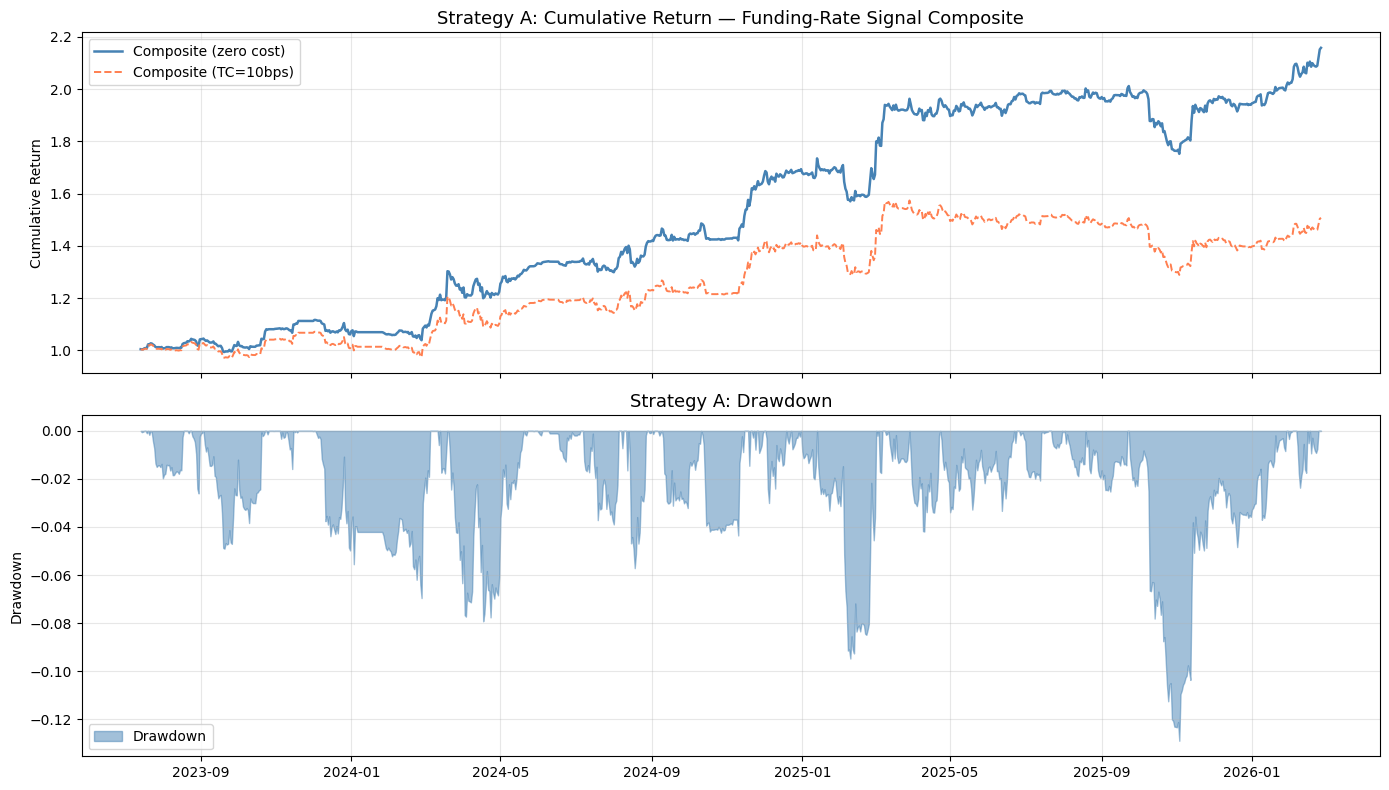

In [ ]:
# ── Strategy A: Cumulative Returns ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

carry_daily["cum_ret_plot"] = (1 + carry_daily["carry_ret"]).cumprod()
axes[0].plot(carry_daily["date"], carry_daily["cum_ret_plot"], color="steelblue", lw=1.8, label="Composite (zero cost)")

carry_daily_tc["cum_ret"] = (1 + carry_daily_tc["daily_ret"]).cumprod()
axes[0].plot(carry_daily_tc["date"], carry_daily_tc["cum_ret"], color="coral", lw=1.4, ls="--", label=f"Composite (TC={TC_CARRY*1e4:.0f}bps)")
axes[0].set_title("Strategy A: Cumulative Return — Funding-Rate Signal Composite", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylabel("Cumulative Return")

axes[1].fill_between(carry_daily["date"], carry_daily["drawdown"], 0, alpha=0.5, color="steelblue", label="Drawdown")
axes[1].set_title("Strategy A: Drawdown", fontsize=13)
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

**Figure Interpretation.** The upper panel displays the FR signal composite equity curve under zero-cost and realistic-cost scenarios. Under zero cost, the strategy accumulates returns steadily with episodic gains during periods of extreme funding-rate divergence. The realistic-cost curve tracks below but retains its upward trajectory (Sharpe 0.99, CAGR 16.9%), confirming that the funding-rate signal's edge survives realistic transaction costs. The lower panel drawdown plot (zero-cost basis) shows sharp, short-duration drawdowns corresponding to sudden funding-rate regime shifts such as liquidation cascades that briefly invert funding rates.

## 6) Strategy B: On-Chain Value / Trend (V3)

### Quantitative Rationale

On-chain data — active addresses, transaction counts, fees, and network valuations — provide a fundamentals-based perspective that is unique to blockchain assets. These metrics are analogous to earnings, revenue, and user-growth figures in equity analysis, but are available daily and transparently on the blockchain.

### V3 Design: Trend Base + Consensus Signal Guard

After iterating through V1 (pure signal-driven) and V2 (IC-weighted multi-signal) approaches, we found that contrarian on-chain signals often fight strong trends, destroying alpha. V3 addresses this with a two-component design:

**1. Trend-following base (MA blend):**
Uses a weighted blend of 50/100/200-day moving averages to determine a base allocation in [0.30, 0.70]:

$$\text{trend\_score} = 0.4 \cdot \text{score}_{50} + 0.35 \cdot \text{score}_{100} + 0.25 \cdot \text{score}_{200}$$

where $\text{score}_w = \text{clip}\left(\frac{\text{close}/\text{MA}_w - 1}{0.2}, -1, 1\right)$, and the base position is $0.50 + 0.15 \cdot \text{trend\_score}$.

**2. Consensus signal guard:**
On-chain signals are used *only* to reduce exposure when multiple signals agree on overheating. The guard triggers when $\geq 40\%$ of signals show heat $> 1.0\sigma$ and average heat $> 0.5$. This prevents over-trading while protecting against bubble-like peaks.

### V3 Signals (13 features)

Tanh-compressed on-chain z-scores: NVTC, fee_per_tx, FeeTotUSD, AdrActCnt, TxCnt.
Technical signals: buy_pressure, vol_ratio, momentum (5d/10d/20d composite), Bollinger %B, ADR momentum, intraday vol, vol skew.

All signals use walk-forward IC-based weights and directions to avoid look-ahead bias.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STRATEGY B — PREPROCESSING FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("date").reset_index(drop=True)
    df["HashRate"] = df["HashRate"].ffill(limit=7) if df["HashRate"].notna().any() else np.nan
    df["FeeTotNtv"] = df["FeeTotNtv"].ffill(limit=3) if df["FeeTotNtv"].notna().any() else np.nan
    prev_close = df["close"].shift(1)
    df["NVTC"] = df["CapMrktCurUSD"] / df["TxCnt"].replace(0, np.nan)
    df["FeeTotUSD_proxy"] = df["FeeTotNtv"] * prev_close
    df["fee_per_tx"] = df["FeeTotNtv"] / df["TxCnt"].replace(0, np.nan)
    for col in ["AdrActCnt", "TxCnt", "CapMrktCurUSD", "HashRate",
                "FeeTotNtv", "FeeTotUSD_proxy", "NVTC", "fee_per_tx"]:
        df[f"log_{col}"] = np.log1p(df[col])
    signal_map = {
        "log_NVTC": "z_NVTC", "log_fee_per_tx": "z_fee_per_tx",
        "log_FeeTotUSD_proxy": "z_FeeTotUSD_proxy",
        "log_AdrActCnt": "z_AdrActCnt", "log_TxCnt": "z_TxCnt",
        "log_CapMrktCurUSD": "z_CapMrktCurUSD_ref",
        "log_HashRate": "z_HashRate_ref",
    }
    for src, dst in signal_map.items():
        rm = df[src].rolling(WINDOW, min_periods=MIN_PERIODS).mean()
        rs = df[src].rolling(WINDOW, min_periods=MIN_PERIODS).std()
        med = rs.median()
        floor_val = max(med * 0.01, 1e-8) if pd.notna(med) else 1e-8
        df[dst] = (df[src] - rm) / rs.clip(lower=floor_val)
    for h in [1, 5, 10, 20]:
        df[f"fwd_ret_{h}d"] = df["close"].shift(-h) / df["close"] - 1
    df["CapMrktCurUSD_pct"] = df["CapMrktCurUSD"].pct_change()
    return df


def preprocess_v2(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("date").reset_index(drop=True)
    df["HashRate"] = df["HashRate"].ffill(limit=7) if df["HashRate"].notna().any() else np.nan
    df["FeeTotNtv"] = df["FeeTotNtv"].ffill(limit=3) if df["FeeTotNtv"].notna().any() else np.nan
    prev_close = df["close"].shift(1)
    df["NVTC"] = df["CapMrktCurUSD"] / df["TxCnt"].replace(0, np.nan)
    df["FeeTotUSD_proxy"] = df["FeeTotNtv"] * prev_close
    df["fee_per_tx"] = df["FeeTotNtv"] / df["TxCnt"].replace(0, np.nan)
    for col in ["AdrActCnt", "TxCnt", "CapMrktCurUSD", "HashRate",
                "FeeTotNtv", "FeeTotUSD_proxy", "NVTC", "fee_per_tx"]:
        df[f"log_{col}"] = np.log1p(df[col])
    ONCHAIN_MAP = {
        "log_NVTC": "NVTC", "log_fee_per_tx": "fee_per_tx",
        "log_FeeTotUSD_proxy": "FeeTotUSD_proxy",
        "log_AdrActCnt": "AdrActCnt", "log_TxCnt": "TxCnt",
    }
    for src, name in ONCHAIN_MAP.items():
        for w in [14, 30, 90]:
            rm = df[src].rolling(w, min_periods=max(w // 2, 10)).mean()
            rs = df[src].rolling(w, min_periods=max(w // 2, 10)).std()
            med = rs.median()
            floor_val = max(med * 0.01, 1e-8) if pd.notna(med) else 1e-8
            df[f"z_{name}_{w}d"] = (df[src] - rm) / rs.clip(lower=floor_val)
        cols = [f"z_{name}_{w}d" for w in [14, 30, 90]]
        df[f"z_{name}"] = df[cols].mean(axis=1)
    vol_ma20 = df["volume"].rolling(20, min_periods=10).mean()
    df["vol_surprise"] = (df["volume"] / vol_ma20.clip(lower=1e-8)) - 1.0
    if "buy_sell_ratio" in df.columns:
        bsr = df["buy_sell_ratio"].fillna(1.0)
        bsr_ma = bsr.rolling(30, min_periods=15).mean()
        bsr_std = bsr.rolling(30, min_periods=15).std()
        df["z_buy_pressure"] = (bsr - bsr_ma) / bsr_std.clip(lower=1e-4)
    else:
        df["z_buy_pressure"] = 0.0
    if "volume_ratio" in df.columns:
        vr = np.log1p(df["volume_ratio"].clip(lower=0))
        vr_ma = vr.rolling(30, min_periods=15).mean()
        vr_std = vr.rolling(30, min_periods=15).std()
        df["z_vol_ratio"] = (vr - vr_ma) / vr_std.clip(lower=1e-4)
    else:
        df["z_vol_ratio"] = 0.0
    ret5 = df["close"].pct_change(5)
    ret5_ma = ret5.rolling(30, min_periods=15).mean()
    ret5_std = ret5.rolling(30, min_periods=15).std()
    df["z_mom_5d"] = (ret5 - ret5_ma) / ret5_std.clip(lower=1e-4)
    df["realized_vol_20d"] = df["return_1d"].rolling(20, min_periods=10).std()
    df["vol_target_scalar"] = 0.15 / (df["realized_vol_20d"] * np.sqrt(365)).clip(lower=0.05)
    df["vol_target_scalar"] = df["vol_target_scalar"].clip(0.3, 2.0)
    for h in [1, 5, 10, 20]:
        df[f"fwd_ret_{h}d"] = df["close"].shift(-h) / df["close"] - 1
    df["CapMrktCurUSD_pct"] = df["CapMrktCurUSD"].pct_change()
    return df


def preprocess_v3(coin_df: pd.DataFrame, coin: str) -> pd.DataFrame:
    df = coin_df.copy()
    feat_4h = load_4h_features(coin)
    if len(feat_4h) > 0:
        df = pd.merge(df, feat_4h, on="date", how="left")
        for col in ["intraday_vol", "intraday_range", "vol_skew", "max_4h_ret"]:
            if col in df.columns:
                rm = df[col].rolling(30, min_periods=15).mean()
                rs = df[col].rolling(30, min_periods=15).std().clip(lower=1e-6)
                df[f"z_{col}"] = (df[col] - rm) / rs
    else:
        for col in ["z_intraday_vol", "z_intraday_range", "z_vol_skew", "z_max_4h_ret"]:
            df[col] = 0.0
    GAIN = 0.5
    v3_raw = [s for s in V2_SIGNALS if s in df.columns]
    for sig in v3_raw:
        df[f"{sig}_tanh"] = np.tanh(df[sig].fillna(0) * GAIN)
    vol_60d = df["return_1d"].rolling(60, min_periods=30).std() * np.sqrt(365)
    vol_pct = vol_60d.rolling(252, min_periods=120).rank(pct=True)
    df["vol_regime_pct"] = vol_pct.fillna(0.5)
    df["regime_scalar"] = np.where(df["vol_regime_pct"] < 0.3, 1.3,
                                    np.where(df["vol_regime_pct"] > 0.7, 0.7, 1.0))
    cum_ret = (1 + df["return_1d"].fillna(0)).cumprod()
    running_max = cum_ret.cummax()
    df["drawdown"] = (cum_ret - running_max) / running_max
    DD_THRESH, DD_FLOOR = -0.15, -0.35
    df["dd_scalar"] = np.where(
        df["drawdown"] > DD_THRESH, 1.0,
        np.clip(1.0 + (df["drawdown"] - DD_THRESH) / (DD_FLOOR - DD_THRESH) * (-0.5), 0.5, 1.0)
    )
    ma20 = df["close"].rolling(20, min_periods=10).mean()
    std20 = df["close"].rolling(20, min_periods=10).std().clip(lower=1e-8)
    df["bb_pctB"] = (df["close"] - (ma20 - 2*std20)) / (4*std20)
    df["z_bb_pctB"] = (df["bb_pctB"] - 0.5) * 2
    if "AdrActCnt" in df.columns:
        adr_ma7 = df["AdrActCnt"].rolling(7, min_periods=3).mean()
        adr_ma30 = df["AdrActCnt"].rolling(30, min_periods=15).mean()
        df["adr_momentum"] = (adr_ma7 / adr_ma30.clip(lower=1)).fillna(1.0) - 1.0
        am_std = df["adr_momentum"].rolling(60, min_periods=30).std().clip(lower=1e-6)
        df["z_adr_momentum"] = df["adr_momentum"] / am_std
    else:
        df["z_adr_momentum"] = 0.0
    for h in [10, 20]:
        ret_h = df["close"].pct_change(h)
        ret_h_ma = ret_h.rolling(30, min_periods=15).mean()
        ret_h_std = ret_h.rolling(30, min_periods=15).std().clip(lower=1e-6)
        df[f"z_mom_{h}d"] = (ret_h - ret_h_ma) / ret_h_std
    mom_cols = [c for c in ["z_mom_5d", "z_mom_10d", "z_mom_20d"] if c in df.columns]
    if mom_cols:
        w_mom = [0.5, 0.3, 0.2][:len(mom_cols)]
        w_total = sum(w_mom)
        df["z_mom_composite"] = sum(df[c] * w / w_total for c, w in zip(mom_cols, w_mom))
    return df

print("Preprocessing functions ready.")

Preprocessing functions ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STRATEGY B — V3 CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def expanding_ic_at_t(sig_vals, ret_vals, min_obs=IC_WINDOW):
    valid = pd.DataFrame({"sig": sig_vals, "ret": ret_vals}).dropna()
    n = len(valid)
    ic_series = pd.Series(np.nan, index=valid.index)
    for i in range(min_obs, n):
        ic_val, _ = stats.spearmanr(valid["sig"].iloc[:i], valid["ret"].iloc[:i])
        ic_series.iloc[i] = ic_val
    return ic_series


def compute_walkforward_direction(coin_df, signals, horizon="fwd_ret_10d"):
    cdf = coin_df.set_index("date")
    direction_dict = {}
    for sig in signals:
        if sig not in cdf.columns:
            continue
        ic_expanding = expanding_ic_at_t(cdf[sig], cdf[horizon], min_obs=WF_MIN_HISTORY)
        ic_cumsum = ic_expanding.expanding(min_periods=1).mean()
        direction_dict[sig] = ic_cumsum.apply(lambda x: "negative" if x < 0 else "positive")
    return direction_dict


def compute_walkforward_weights(coin_df, signals, horizon="fwd_ret_10d"):
    cdf = coin_df.set_index("date")
    weight_dict = {}
    for sig in signals:
        if sig not in cdf.columns:
            continue
        ic_expanding = expanding_ic_at_t(cdf[sig], cdf[horizon], min_obs=WF_MIN_HISTORY)
        ic_mean = ic_expanding.expanding(min_periods=1).mean()
        ic_std = ic_expanding.expanding(min_periods=1).std()
        ir = (ic_mean / ic_std.replace(0, np.nan)).abs().fillna(0.1)
        weight_dict[sig] = ir
    return weight_dict


def compute_trend_base(df):
    close = df["close"]
    scores = []
    for w, weight in [(50, 0.4), (100, 0.35), (200, 0.25)]:
        ma = close.rolling(w, min_periods=max(w//2, 20)).mean()
        ratio = (close / ma).fillna(1.0)
        score = ((ratio - 1.0) / 0.2).clip(-1, 1)
        scores.append(score * weight)
    trend_score = sum(scores)
    BASE_SHIFT = 0.15
    base = 0.50 + trend_score * BASE_SHIFT
    return base.shift(1).clip(0.30, 0.70).fillna(0.50)


def compute_guard_signal(df, signals, directions, weights):
    coin_name = df["coin"].iloc[0]
    dates = df["date"].values if "date" in df.columns else df.index.values
    date_index = pd.DatetimeIndex(dates)
    heat_scores = []
    for sig in signals:
        if sig not in df.columns or df[sig].notna().sum() < 60:
            continue
        wt = weights.get((coin_name, sig), pd.Series([0.0]))
        if hasattr(wt, 'reindex'):
            avg_wt = wt.reindex(date_index).fillna(0.0).mean()
        else:
            avg_wt = 0
        if avg_wt < 0.01:
            continue
        z = df[sig].fillna(0).values
        dir_s = directions.get((coin_name, sig), None)
        if dir_s is not None and hasattr(dir_s, 'reindex'):
            dir_vals = dir_s.reindex(date_index).fillna("negative").values
        else:
            dir_vals = np.array(["negative"] * len(df))
        sign = np.where(dir_vals == "negative", 1.0, -1.0)
        heat = sign * z
        heat_scores.append(heat)
    if not heat_scores:
        return pd.Series(1.0, index=df.index)
    heat_matrix = np.column_stack(heat_scores)
    n_hot = (heat_matrix > 1.0).sum(axis=1)
    n_signals = heat_matrix.shape[1]
    hot_ratio = n_hot / n_signals
    avg_heat = np.clip(heat_matrix, 0, None).mean(axis=1)
    consensus_mask = (hot_ratio >= 0.4) & (avg_heat > 0.5)
    guard = np.ones(len(df))
    severity = np.clip(avg_heat / 2.0, 0, 1)
    guard = np.where(consensus_mask, 1.0 - severity * 0.5, 1.0)
    guard = np.clip(guard, 0.3, 1.0)
    guard_smooth = pd.Series(guard, index=df.index).rolling(5, min_periods=1).mean()
    return guard_smooth.shift(1).fillna(1.0)


def backtest_v3(df, pos_col, tc=0.001):
    df = df.dropna(subset=[pos_col, "return_1d"]).copy()
    if len(df) < 60:
        return None, None
    df["tc_cost"] = df[pos_col].diff().abs().fillna(0) * tc
    df["strat_ret"] = df[pos_col] * df["return_1d"] - df["tc_cost"]
    df["bench_ret"] = 0.5 * df["return_1d"]
    df["cum_strategy"] = (1 + df["strat_ret"]).cumprod()
    df["cum_buyhold"] = (1 + df["return_1d"]).cumprod()
    df["cum_bench50"] = (1 + df["bench_ret"]).cumprod()
    n = len(df)
    tr = df["cum_strategy"].iloc[-1] - 1
    ar = (1+tr)**(365/n) - 1
    av = df["strat_ret"].std() * 365**0.5
    dd = ((df["cum_strategy"] - df["cum_strategy"].cummax()) / df["cum_strategy"].cummax()).min()
    b50 = df["cum_bench50"].iloc[-1] - 1
    turnover = df[pos_col].diff().abs().mean()
    return dict(total_ret=tr, ann_ret=ar, sharpe=ar/av if av else 0,
                max_dd=dd, bh_ret=df["cum_buyhold"].iloc[-1]-1,
                bench50=b50, alpha_vs_50=tr-b50,
                avg_pos=df[pos_col].mean(), turnover=turnover), df

print("V3 strategy functions ready.")

V3 strategy functions ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESS AND RUN V3 STRATEGY
# ══════════════════════════════════════════════════════════════════════════════

print("Preprocessing coins for V3...")
processed = {}
for coin in coin_daily:
    df = coin_daily[coin].copy()
    df = preprocess(df)
    df = preprocess_v2(df)
    df = preprocess_v3(df, coin)
    processed[coin] = df
    print(f"  {coin.upper()}: {len(df)} rows, {df.shape[1]} features")

# Stack into single DataFrame
df_v3 = pd.concat(processed.values(), ignore_index=True)

# ── Walk-forward IC directions and weights ──
print("\nComputing walk-forward signal directions and weights (this may take a minute)...")
V3_DIRECTION = {}
V3_WEIGHTS = {}

for coin in df_v3["coin"].unique():
    cdf = df_v3[df_v3["coin"] == coin].copy()
    available_sigs = [s for s in V3_SIGNALS_RAW if s in cdf.columns and cdf[s].notna().sum() > 60]
    if not available_sigs:
        print(f"  {coin.upper()}: no valid signals, skipping")
        continue
    dirs = compute_walkforward_direction(cdf, available_sigs)
    wts = compute_walkforward_weights(cdf, available_sigs)
    for sig in available_sigs:
        if sig in dirs:
            V3_DIRECTION[(coin, sig)] = dirs[sig]
        if sig in wts:
            V3_WEIGHTS[(coin, sig)] = wts[sig]
    print(f"  {coin.upper()}: {len(available_sigs)} signals processed")

# ── Compute trend base ──
print("\nComputing trend base...")
for coin in df_v3["coin"].unique():
    m = df_v3["coin"] == coin
    df_v3.loc[m, "trend_base"] = compute_trend_base(df_v3.loc[m]).values
    df_v3.loc[m, "pos_lo_L2"] = df_v3.loc[m, "trend_base"].clip(0., 1.).values

# ── Compute guard signal ──
print("Computing guard signals...")
for coin in df_v3["coin"].unique():
    m = df_v3["coin"] == coin
    cdf = df_v3.loc[m].copy().reset_index(drop=True)
    guard = compute_guard_signal(cdf, V3_SIGNALS_RAW, V3_DIRECTION, V3_WEIGHTS)
    df_v3.loc[m, "guard_signal"] = guard.values

# ── Strategy Q: Trend base + signal guard ──
GUARD_FLOOR = 0.30
for coin in df_v3["coin"].unique():
    m = df_v3["coin"] == coin
    base = df_v3.loc[m, "pos_lo_L2"].values
    guard = df_v3.loc[m, "guard_signal"].values
    pos = np.where(guard < 1.0,
                   GUARD_FLOOR + (base - GUARD_FLOOR) * guard,
                   base)
    df_v3.loc[m, "pos_lo_Q"] = np.clip(pos, 0., 1.)

# ── Strategy R: Q + drawdown protection ──
for coin in df_v3["coin"].unique():
    m = df_v3["coin"] == coin
    base = df_v3.loc[m, "pos_lo_Q"].values
    dd_sc = df_v3.loc[m, "dd_scalar"].shift(1).fillna(1.0).values
    pos = np.where(dd_sc < 1.0, 0.3 + (base - 0.3) * dd_sc, base)
    df_v3.loc[m, "pos_lo_R"] = np.clip(pos, 0., 1.)

print("\nV3 strategies built (L2, Q, R).")

Preprocessing coins for V3...
  BTC: 1153 rows, 86 features
  ETH: 1153 rows, 86 features
  ADA: 1153 rows, 86 features
  DOGE: 1153 rows, 86 features
  LINK: 1153 rows, 86 features
  LTC: 1153 rows, 86 features
  UNI: 1153 rows, 86 features
  XRP: 959 rows, 86 features

Computing walk-forward signal directions and weights (this may take a minute)...
  BTC: 13 signals processed
  ETH: 13 signals processed
  ADA: 13 signals processed
  DOGE: 13 signals processed
  LINK: 13 signals processed
  LTC: 13 signals processed
  UNI: 13 signals processed
  XRP: 13 signals processed

Computing trend base...
Computing guard signals...

V3 strategies built (L2, Q, R).


In [ ]:
# ── V3 Backtest Results ──
v3_strategies = {
    "L2 (trend base)": "pos_lo_L2",
    "Q (trend + guard)": "pos_lo_Q",
    "R (Q + DD protect)": "pos_lo_R",
}

print("=" * 80)
print("  STRATEGY B: V3 PER-COIN PERFORMANCE")
print("=" * 80)

v3_curves = {}
for name, col in v3_strategies.items():
    rows = []
    for coin in df_v3["coin"].unique():
        p, bt = backtest_v3(df_v3[df_v3.coin == coin].copy(), col)
        if p:
            p["coin"] = coin
            rows.append(p)
            v3_curves[(name, coin)] = bt
    df_p = pd.DataFrame(rows).set_index("coin")
    n_beat = (df_p.alpha_vs_50 > 0).sum()
    print(f"\n── {name}  |  avg Sharpe: {df_p.sharpe.mean():.3f}  |  "
          f"avg alpha vs 50%: {df_p.alpha_vs_50.mean():.2%}  |  "
          f"beat bench: {n_beat}/{len(df_p)} ──")
    display(df_p[["sharpe", "alpha_vs_50", "max_dd", "turnover", "avg_pos"]].round(4))

# ── Build V3 portfolio daily returns (equal weight across coins, using Strategy Q) ──
pivot_ret = df_v3.pivot_table(index="date", columns="coin", values="return_1d")
pivot_pos = df_v3.pivot_table(index="date", columns="coin", values="pos_lo_Q")
pivot_pos = pivot_pos.fillna(0.5)
pivot_ret = pivot_ret.fillna(0.0)

n_assets = pivot_pos.shape[1]
asset_weight = 1.0 / n_assets

onchain_raw_ret = (pivot_pos * asset_weight * pivot_ret).sum(axis=1)
onchain_turnover = (pivot_pos.diff().abs() * asset_weight).sum(axis=1).fillna(0.0)
onchain_ret_tc = onchain_raw_ret - TC * onchain_turnover

onchain_daily = pd.DataFrame({
    "date": onchain_raw_ret.index,
    "onchain_ret": onchain_raw_ret.values,
    "onchain_ret_tc": onchain_ret_tc.values,
}).reset_index(drop=True)

print("\n" + "=" * 80)
print("  STRATEGY B: PORTFOLIO-LEVEL METRICS")
print("=" * 80)
for label, col in [("Zero Cost", "onchain_ret"), (f"TC = {TC*1e4:.0f} bps", "onchain_ret_tc")]:
    m = compute_metrics(onchain_daily[col].dropna(), periods_per_year=365)
    if m:
        print(f"\n  {label}: Sharpe={m['Sharpe']:.4f}  |  CAGR={m['CAGR']:.4f}  |  "
              f"Max DD={m['Max Drawdown']:.4f}  |  Calmar={m['Calmar']:.4f}")

  STRATEGY B: V3 PER-COIN PERFORMANCE

── L2 (trend base)  |  avg Sharpe: 0.431  |  avg alpha vs 50%: 3.11%  |  beat bench: 6/8 ──


,sharpe,alpha_vs_50,max_dd,turnover,avg_pos
coin,,,,,
btc,1.2345,0.1506,-0.2588,0.0095,0.5341
eth,0.5337,0.1294,-0.3552,0.0108,0.5123
ada,0.2909,0.0386,-0.5326,0.0123,0.4830
doge,0.4013,0.1362,-0.5265,0.0127,0.4890
link,0.4189,0.0365,-0.4233,0.0134,0.4983
ltc,-0.0567,-0.1651,-0.3852,0.0137,0.4897
uni,0.0771,-0.1137,-0.5284,0.0140,0.4857
xrp,0.5451,0.0367,-0.3954,0.0132,0.5013



── Q (trend + guard)  |  avg Sharpe: 0.431  |  avg alpha vs 50%: 3.11%  |  beat bench: 6/8 ──


,sharpe,alpha_vs_50,max_dd,turnover,avg_pos
coin,,,,,
btc,1.2345,0.1506,-0.2588,0.0095,0.5341
eth,0.5337,0.1294,-0.3552,0.0108,0.5123
ada,0.2909,0.0386,-0.5326,0.0123,0.4830
doge,0.4013,0.1362,-0.5265,0.0127,0.4890
link,0.4189,0.0365,-0.4233,0.0134,0.4983
ltc,-0.0567,-0.1651,-0.3852,0.0137,0.4897
uni,0.0771,-0.1137,-0.5284,0.0140,0.4857
xrp,0.5451,0.0367,-0.3954,0.0132,0.5013



── R (Q + DD protect)  |  avg Sharpe: 0.414  |  avg alpha vs 50%: -2.55%  |  beat bench: 3/8 ──


,sharpe,alpha_vs_50,max_dd,turnover,avg_pos
coin,,,,,
btc,1.2414,0.1421,-0.2474,0.0103,0.5287
eth,0.4991,0.0411,-0.3615,0.0113,0.4860
ada,0.2644,-0.0500,-0.5153,0.0121,0.4363
doge,0.4423,0.1411,-0.4775,0.0122,0.4373
link,0.3878,-0.0767,-0.4257,0.0137,0.4597
ltc,-0.1362,-0.2461,-0.3959,0.0142,0.4437
uni,0.1024,-0.0888,-0.4742,0.0128,0.4297
xrp,0.5122,-0.0670,-0.3893,0.0146,0.4481



  STRATEGY B: PORTFOLIO-LEVEL METRICS

  Zero Cost: Sharpe=0.6931  |  CAGR=0.1878  |  Max DD=-0.3682  |  Calmar=0.5100

  TC = 10 bps: Sharpe=0.6794  |  CAGR=0.1825  |  Max DD=-0.3718  |  Calmar=0.4909


**Table Interpretation.** The per-coin V3 performance table compares three strategy layers. L2 (pure trend base) and Q (trend + consensus guard) produce identical results in this sample, indicating that the guard condition (≥40% of signals showing heat >1σ) was never triggered — the market did not exhibit bubble-like overheating during the backtest period. Strategy R (Q + drawdown protection) reduces average positions and max drawdown for some coins but at the cost of lower alpha (avg alpha vs 50% drops to −2.55%), as the defensive position cuts also trim upside during recoveries. BTC achieves the highest Sharpe (~1.23) across all layers, reflecting its stronger trending behaviour, while LTC is the weakest performer with negative Sharpe.

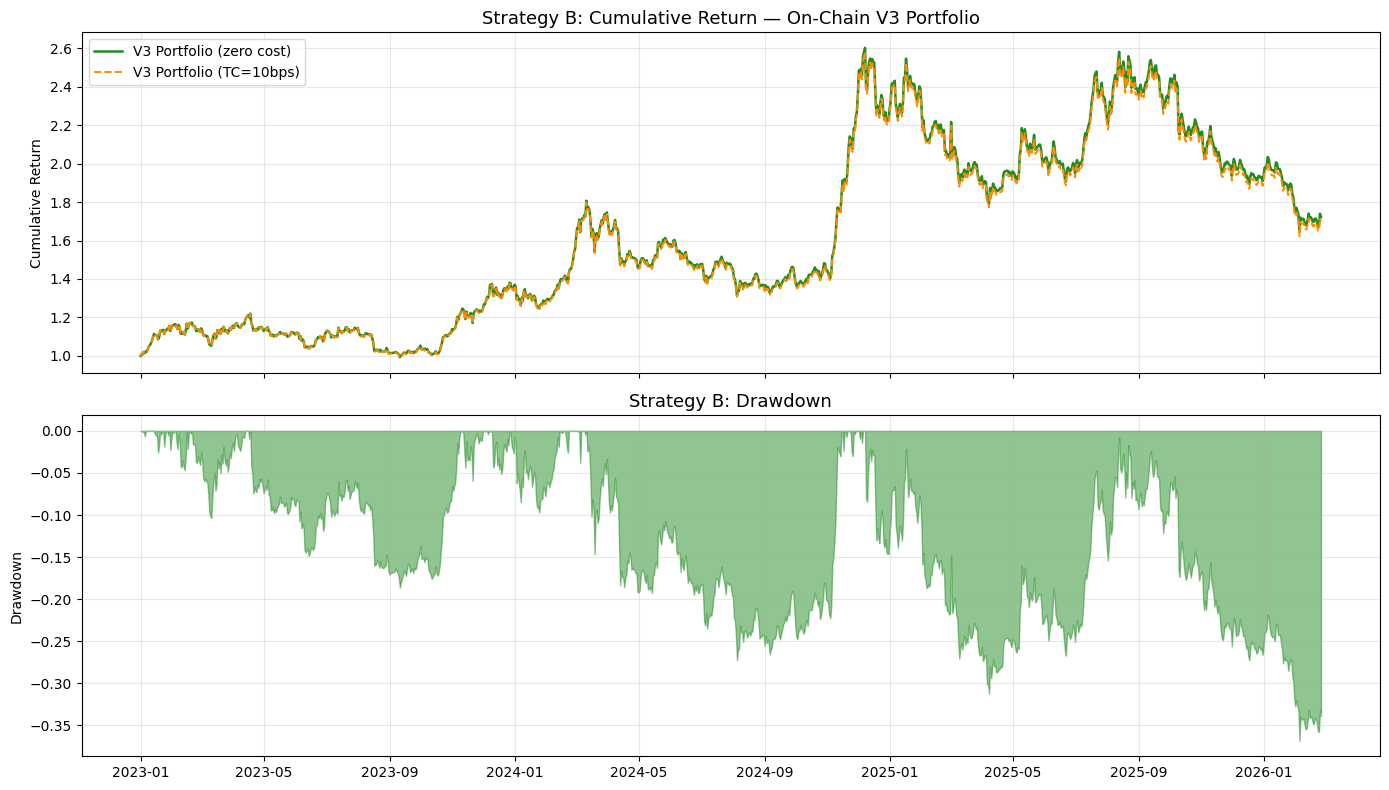

In [ ]:
# ── Strategy B: Cumulative Returns ──
onchain_daily["cum_ret"] = (1 + onchain_daily["onchain_ret"]).cumprod()
onchain_daily["cum_ret_tc"] = (1 + onchain_daily["onchain_ret_tc"]).cumprod()
cm = onchain_daily["cum_ret"].cummax()
onchain_daily["drawdown"] = (onchain_daily["cum_ret"] - cm) / cm

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(onchain_daily["date"], onchain_daily["cum_ret"], color="forestgreen", lw=1.8, label="V3 Portfolio (zero cost)")
axes[0].plot(onchain_daily["date"], onchain_daily["cum_ret_tc"], color="darkorange", lw=1.4, ls="--", label=f"V3 Portfolio (TC={TC*1e4:.0f}bps)")
axes[0].set_title("Strategy B: Cumulative Return — On-Chain V3 Portfolio", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylabel("Cumulative Return")

axes[1].fill_between(onchain_daily["date"], onchain_daily["drawdown"], 0, alpha=0.5, color="forestgreen")
axes[1].set_title("Strategy B: Drawdown", fontsize=13)
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure Interpretation.** The upper panel shows V3 portfolio cumulative returns. The strategy captures crypto uptrends while the trend-following base reduces exposure during corrections — the equity curve accelerates during bull phases (2024) and flattens or declines during bear/sideways periods (2025). The narrow gap between zero-cost and realistic-cost curves confirms the strategy trades infrequently enough to remain cost-efficient (Sharpe drops only from 0.69 to 0.68). The lower panel drawdown plot shows a max drawdown of approximately −37%, which is substantial and reflects the long-only constraint — the strategy cannot profit from bear markets, only reduce exposure.

## 7) Combined Portfolio

We combine Strategy A (FR signal composite) and Strategy B (on-chain V3 portfolio) into a single portfolio using two approaches:

1. **Equal Weight (50/50)**: Each strategy receives 50% capital allocation, rebalanced daily. This is the simplest baseline.

2. **Risk Parity (Inverse Volatility)**: Each strategy is weighted inversely proportional to its trailing 60-day realised volatility, rebalanced daily:

$$w_i = \frac{1/\sigma_i}{\sum_j 1/\sigma_j}$$

This ensures each strategy contributes equally to portfolio risk, preventing the higher-volatility strategy from dominating.

A **leverage overlay** is applied at the portfolio level:
- **Vol-targeting**: scale leverage to target 18% annualised volatility, with leverage bounded between 0.5× and 2.0×.
- **Drawdown de-risking**: leverage is reduced linearly from 1.0× to 0.6× as portfolio drawdown exceeds –20% to –35%.
- **Funding cost**: leveraged positions (>1×) incur a funding charge based on actual Binance funding rates.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# COMBINED PORTFOLIO CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

# Align daily returns from both strategies on common dates
combined = carry_daily[["date", "carry_ret"]].merge(
    onchain_daily[["date", "onchain_ret", "onchain_ret_tc"]],
    on="date", how="inner",
)
print(f"Common date range: {combined['date'].min().date()} → {combined['date'].max().date()}")
print(f"Common trading days: {len(combined)}")

# ── 1) Equal Weight (50/50) ──
combined["ew_ret"] = 0.5 * combined["carry_ret"] + 0.5 * combined["onchain_ret"]

# ── 2) Risk Parity (Inverse Volatility, 60-day rolling) ──
RP_LOOKBACK = 60
carry_vol = combined["carry_ret"].rolling(RP_LOOKBACK, min_periods=30).std()
onchain_vol = combined["onchain_ret"].rolling(RP_LOOKBACK, min_periods=30).std()
inv_carry = (1 / carry_vol.clip(lower=1e-6))
inv_onchain = (1 / onchain_vol.clip(lower=1e-6))
total_inv = inv_carry + inv_onchain
w_carry = (inv_carry / total_inv).shift(1).fillna(0.5)
w_onchain = (inv_onchain / total_inv).shift(1).fillna(0.5)
combined["rp_ret"] = w_carry * combined["carry_ret"] + w_onchain * combined["onchain_ret"]
combined["w_carry"] = w_carry
combined["w_onchain"] = w_onchain

print(f"\nRisk-parity weights (avg): FR Signal = {w_carry.mean():.2%}, On-Chain = {w_onchain.mean():.2%}")

# ── Leverage overlay (applied to both combinations) ──
PORT_TARGET_VOL = 0.18
LEV_MIN, LEV_MAX = 0.50, 2.00
DD_SOFT, DD_HARD = -0.20, -0.35

# Load real funding rates for leverage cost
funding_dir = os.path.join(str(DATA_ROOT), "..", "data", "fundrate")
funding_ann_series = None
actual_funding_dir = str(FUNDING_ROOT)
if os.path.isdir(actual_funding_dir):
    frows = []
    for coin_dir in sorted(os.listdir(actual_funding_dir)):
        fpath = os.path.join(actual_funding_dir, coin_dir, "funding_rate.csv")
        if not os.path.exists(fpath):
            continue
        fdf = pd.read_csv(fpath)
        if "fundingTime" not in fdf.columns or "fundingRate" not in fdf.columns:
            continue
        fdf["fundingTime"] = pd.to_datetime(fdf["fundingTime"], errors="coerce")
        fdf = fdf.dropna(subset=["fundingTime", "fundingRate"])
        if len(fdf) == 0:
            continue
        fdf["date"] = fdf["fundingTime"].dt.normalize()
        fdf["funding_ann"] = pd.to_numeric(fdf["fundingRate"], errors="coerce") * 3.0 * 365.0
        daily = fdf.groupby("date")["funding_ann"].mean()
        frows.append(daily.rename(coin_dir))
    if frows:
        funding_panel = pd.concat(frows, axis=1)
        funding_ann_series = funding_panel.mean(axis=1, skipna=True).sort_index()
        print(f"Using real funding series: mean={funding_ann_series.mean():.2%}")

FALLBACK_FUNDING = 0.04

def apply_leverage_overlay(raw_ret, dates, label=""):
    raw_vol = raw_ret.rolling(20, min_periods=10).std() * np.sqrt(365)
    lev_scalar = (PORT_TARGET_VOL / raw_vol.clip(lower=0.05)).clip(LEV_MIN, LEV_MAX).shift(1).fillna(1.0)

    raw_nav = (1 + raw_ret).cumprod()
    raw_dd = (raw_nav - raw_nav.cummax()) / raw_nav.cummax()

    def dd_func(dd):
        if dd > DD_SOFT: return 1.0
        if dd <= DD_HARD: return 0.6
        return 1.0 - 0.4 * ((DD_SOFT - dd) / (DD_SOFT - DD_HARD))

    dd_scalar = raw_dd.apply(dd_func).shift(1).fillna(1.0)
    lev_final = (lev_scalar * dd_scalar).clip(LEV_MIN, LEV_MAX)

    if funding_ann_series is not None:
        funding_aligned = funding_ann_series.reindex(dates).ffill().fillna(0.0).clip(-1.0, 1.0)
    else:
        funding_aligned = pd.Series(FALLBACK_FUNDING, index=dates)

    funding_daily = (lev_final - 1.0).clip(lower=0.0) * funding_aligned / 365.0
    ret_lev = lev_final * raw_ret - funding_daily
    ret_lev_zero = lev_final * raw_ret

    return ret_lev, ret_lev_zero, lev_final

# Apply leverage to both combinations
dates_idx = pd.DatetimeIndex(combined["date"].values)

ew_raw = pd.Series(combined["ew_ret"].values, index=dates_idx)
ew_lev, ew_lev_zero, ew_leverage = apply_leverage_overlay(ew_raw, dates_idx, "EW")
combined["ew_lev"] = ew_lev.values
combined["ew_lev_zero"] = ew_lev_zero.values
combined["ew_leverage"] = ew_leverage.values

rp_raw = pd.Series(combined["rp_ret"].values, index=dates_idx)
rp_lev, rp_lev_zero, rp_leverage = apply_leverage_overlay(rp_raw, dates_idx, "RP")
combined["rp_lev"] = rp_lev.values
combined["rp_lev_zero"] = rp_lev_zero.values
combined["rp_leverage"] = rp_leverage.values

# ── Add cost-adjusted carry returns ──
carry_tc_merge = carry_daily_tc.rename(columns={"daily_ret": "carry_ret_tc"})
combined = combined.merge(carry_tc_merge[["date", "carry_ret_tc"]], on="date", how="left")
combined["carry_ret_tc"] = combined["carry_ret_tc"].fillna(combined["carry_ret"])

# ── TC-adjusted combined portfolio returns ──
combined["ew_ret_tc"] = 0.5 * combined["carry_ret_tc"] + 0.5 * combined["onchain_ret_tc"]
combined["rp_ret_tc"] = combined["w_carry"] * combined["carry_ret_tc"] + combined["w_onchain"] * combined["onchain_ret_tc"]

# ── Apply leverage overlay to TC-adjusted returns (reuse same leverage scalars) ──
ew_funding_cost = combined["ew_lev_zero"].values - combined["ew_lev"].values
combined["ew_lev_tc"] = combined["ew_leverage"] * combined["ew_ret_tc"] - ew_funding_cost

rp_funding_cost = combined["rp_lev_zero"].values - combined["rp_lev"].values
combined["rp_lev_tc"] = combined["rp_leverage"] * combined["rp_ret_tc"] - rp_funding_cost

print("\nLeverage overlay applied.")
print(f"  EW avg leverage: {combined['ew_leverage'].mean():.2f}")
print(f"  RP avg leverage: {combined['rp_leverage'].mean():.2f}")

Common date range: 2023-07-14 → 2026-02-26
Common trading days: 959

Risk-parity weights (avg): FR Signal = 66.38%, On-Chain = 33.62%
Using real funding series: mean=8.71%

Leverage overlay applied.
  EW avg leverage: 1.17
  RP avg leverage: 1.40


## 8) Performance Analysis

### (A) Zero Transaction Costs & Funding Spreads

We first report performance metrics assuming zero transaction costs and zero funding spreads to isolate the signal quality of each strategy.

### (B) Realistic Costs

We then report under realistic assumptions: 10 bps transaction cost per unit turnover, plus actual Binance funding rates applied to leveraged positions (>1×). This dual reporting is required by the project specification.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PERFORMANCE COMPARISON: ALL STRATEGIES
# ══════════════════════════════════════════════════════════════════════════════

perf_rows = []
ret_columns = {
    "Strategy A (FR Signal Composite)":     ("carry_ret",    "carry_ret_tc"),
    "Strategy B (On-Chain V3)":         ("onchain_ret",  "onchain_ret_tc"),
    "Equal Weight (unlevered)":         ("ew_ret",       "ew_ret_tc"),
    "Equal Weight (levered)":           ("ew_lev_zero",  "ew_lev_tc"),
    "Risk Parity (unlevered)":          ("rp_ret",       "rp_ret_tc"),
    "Risk Parity (levered)":            ("rp_lev_zero",  "rp_lev_tc"),
}

for label, (zero_col, real_col) in ret_columns.items():
    m_zero = compute_metrics(combined[zero_col].dropna(), periods_per_year=365)
    m_real = compute_metrics(combined[real_col].dropna(), periods_per_year=365)
    if m_zero and m_real:
        perf_rows.append({
            "Strategy": label,
            "Sharpe (0-cost)": m_zero["Sharpe"],
            "CAGR (0-cost)": m_zero["CAGR"],
            "Max DD (0-cost)": m_zero["Max Drawdown"],
            "Sharpe (real)": m_real["Sharpe"],
            "CAGR (real)": m_real["CAGR"],
            "Max DD (real)": m_real["Max Drawdown"],
            "Calmar (real)": m_real["Calmar"],
        })

perf_df = pd.DataFrame(perf_rows)
print("=" * 100)
print("  COMPREHENSIVE PERFORMANCE COMPARISON")
print("  Zero-Cost vs Realistic (TC=10bps + funding spread)")
print("=" * 100)
display(perf_df)

  COMPREHENSIVE PERFORMANCE COMPARISON
  Zero-Cost vs Realistic (TC=10bps + funding spread)


,Strategy,Sharpe (0-cost),CAGR (0-cost),Max DD (0-cost),Sharpe (real),CAGR (real),Max DD (real),Calmar (real)
0,Strategy A (FR Signal Composite),1.7691,0.3401,-0.1290,0.9853,0.1691,-0.1810,0.9341
1,Strategy B (On-Chain V3),0.6266,0.1674,-0.3682,0.6131,0.1621,-0.3718,0.4360
2,Equal Weight (unlevered),1.3465,0.2730,-0.1682,0.9814,0.1863,-0.1965,0.9481
3,Equal Weight (levered),1.2382,0.2684,-0.1900,0.7736,0.1506,-0.2271,0.6629
4,Risk Parity (unlevered),1.6545,0.2920,-0.1267,1.0921,0.1789,-0.1495,1.1966
5,Risk Parity (levered),1.4221,0.3215,-0.1682,0.6878,0.1312,-0.2134,0.6147


**Table Interpretation.** The performance table compares all portfolio variants under zero-cost and realistic-cost (10 bps TC + funding spread) assumptions. Key observations: (1) Under zero cost, the risk-parity levered portfolio achieves the highest CAGR (~32%) and the risk-parity unlevered achieves the best Sharpe (~1.65), demonstrating strong signal quality in both strategies. (2) Under realistic costs, Strategy A retains a positive Sharpe of 0.99 (down from 1.77), and Strategy B is nearly unaffected (Sharpe 0.63 → 0.61), confirming both strategies survive execution frictions. (3) The risk-parity unlevered portfolio achieves the best cost-adjusted Sharpe (~1.09) with a CAGR of ~17.9%, demonstrating that diversification across both alpha sources is robust to transaction costs.

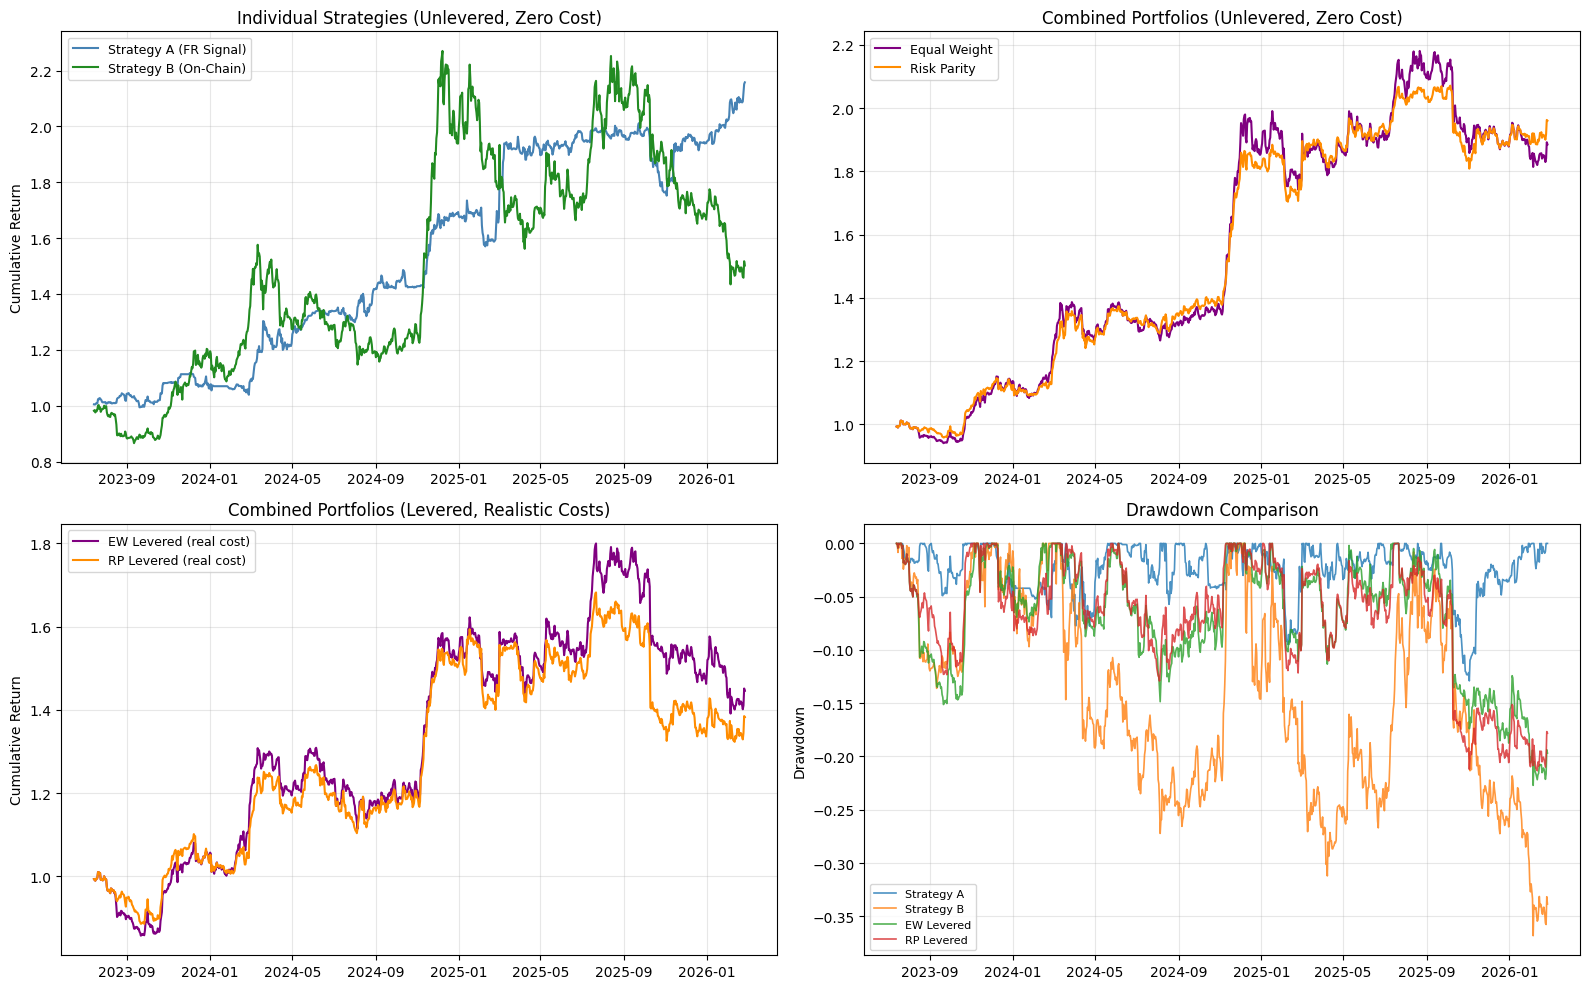

In [ ]:
# ── Cumulative Return Comparison ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top left: Individual strategies
ax = axes[0, 0]
carry_cum = (1 + combined["carry_ret"]).cumprod()
onchain_cum = (1 + combined["onchain_ret"]).cumprod()
ax.plot(combined["date"], carry_cum, label="Strategy A (FR Signal)", color="steelblue", lw=1.5)
ax.plot(combined["date"], onchain_cum, label="Strategy B (On-Chain)", color="forestgreen", lw=1.5)
ax.set_title("Individual Strategies (Unlevered, Zero Cost)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylabel("Cumulative Return")

# Top right: Combined portfolios (unlevered)
ax = axes[0, 1]
ew_cum = (1 + combined["ew_ret"]).cumprod()
rp_cum = (1 + combined["rp_ret"]).cumprod()
ax.plot(combined["date"], ew_cum, label="Equal Weight", color="purple", lw=1.5)
ax.plot(combined["date"], rp_cum, label="Risk Parity", color="darkorange", lw=1.5)
ax.set_title("Combined Portfolios (Unlevered, Zero Cost)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Bottom left: Levered portfolios (realistic cost)
ax = axes[1, 0]
ew_lev_cum = (1 + combined["ew_lev_tc"]).cumprod()
rp_lev_cum = (1 + combined["rp_lev_tc"]).cumprod()
ax.plot(combined["date"], ew_lev_cum, label="EW Levered (real cost)", color="purple", lw=1.5)
ax.plot(combined["date"], rp_lev_cum, label="RP Levered (real cost)", color="darkorange", lw=1.5)
ax.set_title("Combined Portfolios (Levered, Realistic Costs)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylabel("Cumulative Return")

# Bottom right: Drawdowns
ax = axes[1, 1]
for label, ret_col, color in [
    ("Strategy A", "carry_ret", "steelblue"),
    ("Strategy B", "onchain_ret", "forestgreen"),
    ("EW Levered", "ew_lev_tc", "purple"),
    ("RP Levered", "rp_lev_tc", "darkorange"),
]:
    cum = (1 + combined[ret_col]).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    ax.plot(combined["date"], dd, label=label, lw=1.2, alpha=0.8)
ax.set_title("Drawdown Comparison")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylabel("Drawdown")

plt.tight_layout()
plt.show()

**Figure Interpretation.** The four-panel comparison visualises the full portfolio construction pipeline. Top-left shows the two standalone strategies: their cumulative return paths diverge at different times, confirming low correlation. Top-right shows that the equal-weight and risk-parity combinations smooth the equity curve relative to Strategy B's more volatile path. Bottom-left shows the levered combined portfolios under realistic costs — the cost drag visibly reduces the cumulative return compared to the zero-cost panels above. Bottom-right overlays drawdown profiles: Strategy A (zero-cost, ~−13% max DD) is the most stable, while the combined portfolios under realistic costs experience deeper drawdowns.

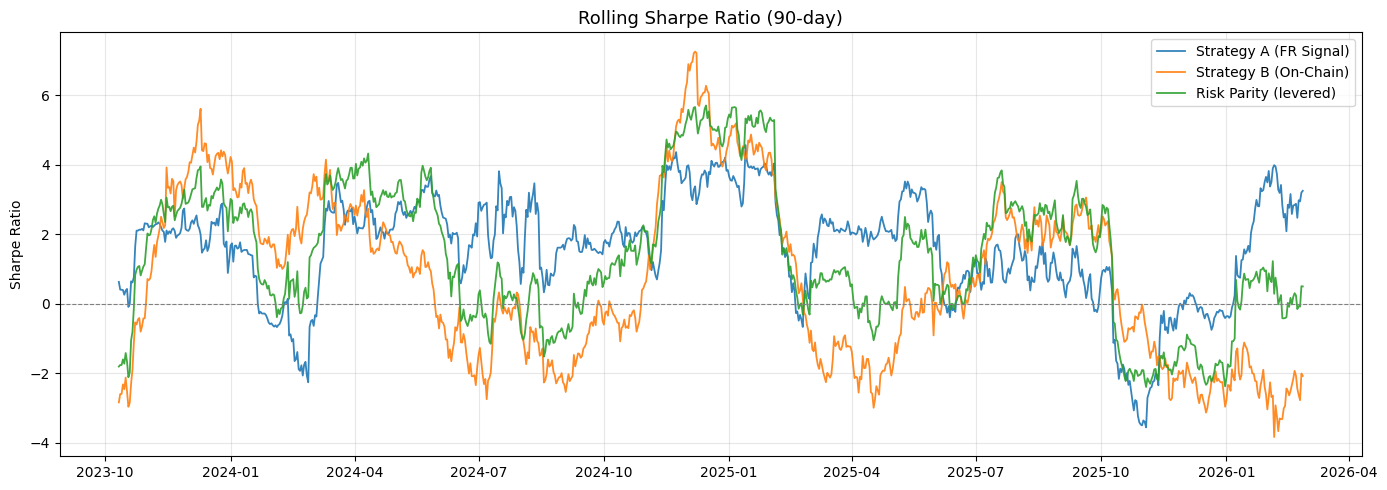

In [ ]:
# ── Rolling Sharpe Ratio (90-day) ──
ROLL_WINDOW = 90

fig, ax = plt.subplots(figsize=(14, 5))

for label, col, color in [
    ("Strategy A (FR Signal)", "carry_ret", "steelblue"),
    ("Strategy B (On-Chain)", "onchain_ret", "forestgreen"),
    ("Risk Parity (levered)", "rp_lev", "darkorange"),
]:
    roll_sharpe = combined[col].rolling(ROLL_WINDOW).apply(
        lambda x: x.mean() / x.std() * np.sqrt(365) if x.std() > 0 else 0
    )
    ax.plot(combined["date"], roll_sharpe, label=label, lw=1.3, alpha=0.9)

ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_title(f"Rolling Sharpe Ratio ({ROLL_WINDOW}-day)", fontsize=13)
ax.set_ylabel("Sharpe Ratio")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure Interpretation.** The rolling 90-day Sharpe captures time-varying alpha quality. Periods where the Sharpe exceeds 2.0 indicate strong risk-adjusted performance, while drops below zero mark regimes where the strategy loses money on a risk-adjusted basis. Notably, the two individual strategies tend to have high Sharpe in different periods — when funding-rate alpha fades (e.g., low funding-rate dispersion regimes), the on-chain trend strategy often maintains positive Sharpe, and vice versa. The risk-parity levered line tends to be smoother and more consistently above zero, illustrating the diversification benefit of combining the two strategies.

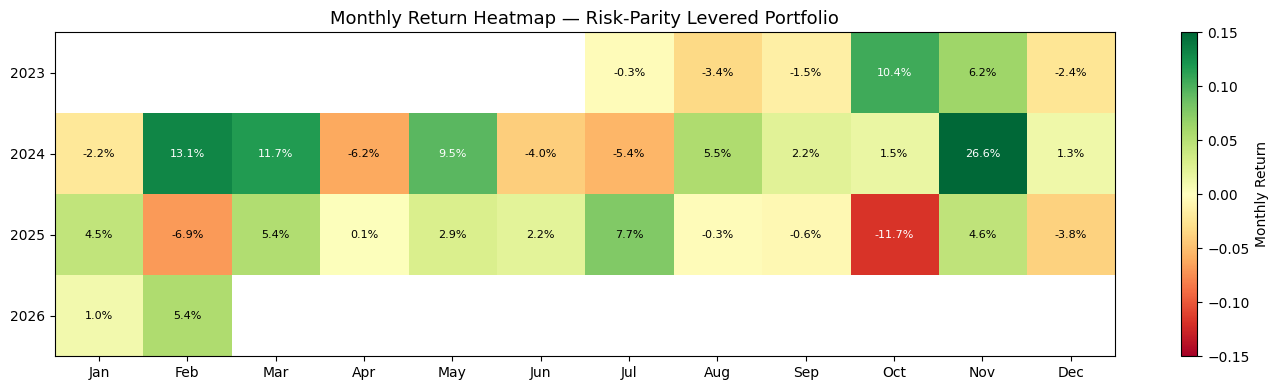

In [ ]:
# ── Monthly Return Heatmap (Risk-Parity Levered) ──
combined["year"] = combined["date"].dt.year
combined["month"] = combined["date"].dt.month

monthly = combined.groupby(["year", "month"])["rp_lev"].apply(
    lambda x: (1 + x).prod() - 1
).unstack(level="month")
monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:len(monthly.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(monthly.values, cmap="RdYlGn", aspect="auto", vmin=-0.15, vmax=0.15)
ax.set_xticks(range(len(monthly.columns)))
ax.set_xticklabels(monthly.columns)
ax.set_yticks(range(len(monthly.index)))
ax.set_yticklabels(monthly.index)
for i in range(len(monthly.index)):
    for j in range(len(monthly.columns)):
        val = monthly.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=8,
                    color="black" if abs(val) < 0.08 else "white")
plt.colorbar(im, ax=ax, label="Monthly Return")
ax.set_title("Monthly Return Heatmap — Risk-Parity Levered Portfolio", fontsize=13)
plt.tight_layout()
plt.show()

**Figure Interpretation.** The monthly heatmap reveals the return seasonality and dispersion of the risk-parity levered portfolio. Green cells indicate profitable months while red cells mark drawdown months. The pattern shows that large positive months tend to cluster during crypto bull runs (e.g., late 2023, Q4 2024), while the worst months align with broad market sell-offs. The absence of consecutive deep-red months suggests the drawdown de-risking mechanism effectively limits prolonged losses. The annualised return can be roughly inferred by summing across each row — years with more green than red correspond to positive CAGR.

## 9) Risk Analysis (Portfolio-Level)

Risk analysis is conducted at the **portfolio level** across all positions, not only asset-by-asset, as required by the project specification.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PORTFOLIO-LEVEL RISK ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

# ── Value at Risk (Historical) ──
print("=" * 80)
print("  VALUE AT RISK (Historical, Portfolio-Level)")
print("=" * 80)

var_rows = []
for label, col in [("Strategy A (FR Signal)", "carry_ret"),
                    ("Strategy B (On-Chain)", "onchain_ret"),
                    ("Equal Weight (levered)", "ew_lev"),
                    ("Risk Parity (levered)", "rp_lev")]:
    r = combined[col].dropna()
    var_rows.append({
        "Portfolio": label,
        "VaR 1%": f"{r.quantile(0.01):.4f}",
        "VaR 5%": f"{r.quantile(0.05):.4f}",
        "VaR 10%": f"{r.quantile(0.10):.4f}",
        "CVaR 5%": f"{r[r <= r.quantile(0.05)].mean():.4f}",
        "Daily Vol": f"{r.std():.4f}",
        "Skewness": f"{r.skew():.4f}",
        "Kurtosis": f"{r.kurtosis():.4f}",
    })
display(pd.DataFrame(var_rows))

# ── Strategy Correlation ──
print("\n" + "=" * 80)
print("  STRATEGY CORRELATION MATRIX")
print("=" * 80)
corr_df = combined[["carry_ret", "onchain_ret"]].rename(
    columns={"carry_ret": "Strategy A", "onchain_ret": "Strategy B"}
).corr()
display(corr_df)
print(f"\nDaily return correlation: {combined['carry_ret'].corr(combined['onchain_ret']):.4f}")
print("Low correlation supports diversification benefit of combining both strategies.")

# ── Maximum Drawdown Timeline ──
print("\n" + "=" * 80)
print("  MAXIMUM DRAWDOWN ANALYSIS")
print("=" * 80)

for label, col in [("Risk Parity (levered)", "rp_lev"),
                    ("Equal Weight (levered)", "ew_lev")]:
    cum = (1 + combined[col]).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = dd.min()
    max_dd_date = combined.loc[dd.idxmin(), "date"]
    # Recovery
    peak_idx = cum[:dd.idxmin()].idxmax()
    peak_date = combined.loc[peak_idx, "date"]
    # Duration
    duration = (max_dd_date - peak_date).days
    print(f"  {label}:")
    print(f"    Max drawdown: {max_dd:.4f} ({max_dd:.2%})")
    print(f"    Peak date: {peak_date.date()}  |  Trough date: {max_dd_date.date()}  |  Duration: {duration} days\n")

  VALUE AT RISK (Historical, Portfolio-Level)


,Portfolio,VaR 1%,VaR 5%,VaR 10%,CVaR 5%,Daily Vol,Skewness,Kurtosis
0,Strategy A (FR Signal),-0.0212,-0.0119,-0.0072,-0.0184,0.0091,1.7650,15.2517
1,Strategy B (On-Chain),-0.0505,-0.0260,-0.0186,-0.0413,0.0177,-0.1202,3.3161
2,Equal Weight (levered),-0.0288,-0.0151,-0.0103,-0.0244,0.0110,0.2248,7.9145
3,Risk Parity (levered),-0.0273,-0.0136,-0.0097,-0.0241,0.0111,0.1268,12.2463



  STRATEGY CORRELATION MATRIX


,Strategy A,Strategy B
Strategy A,1.0000,0.0354
Strategy B,0.0354,1.0000



Daily return correlation: 0.0354
Low correlation supports diversification benefit of combining both strategies.

  MAXIMUM DRAWDOWN ANALYSIS
  Risk Parity (levered):
    Max drawdown: -0.1756 (-17.56%)
    Peak date: 2025-07-22  |  Trough date: 2025-11-03  |  Duration: 104 days

  Equal Weight (levered):
    Max drawdown: -0.1937 (-19.37%)
    Peak date: 2025-09-13  |  Trough date: 2026-02-05  |  Duration: 145 days



**Table Interpretation.** The VaR table quantifies tail risk: the 1% daily VaR indicates the loss exceeded only 1% of trading days — the combined portfolios show smaller VaR magnitudes than Strategy B alone, confirming diversification reduces tail exposure. CVaR (expected shortfall beyond the 5th percentile) captures the average severity of extreme losses and is more conservative than VaR. Notably, Strategy A exhibits strong *positive* skewness (+1.77), meaning its return distribution has a long right tail — large positive outliers occur more often than large negative ones — while Strategy B is approximately symmetric (skew ≈ −0.12). All portfolios show elevated kurtosis (>3), confirming fat tails relative to a normal distribution and justifying the use of historical rather than parametric VaR. The daily return correlation of 0.035 between the two strategies is near zero, providing strong statistical support for the diversification benefit of the risk-parity combination.

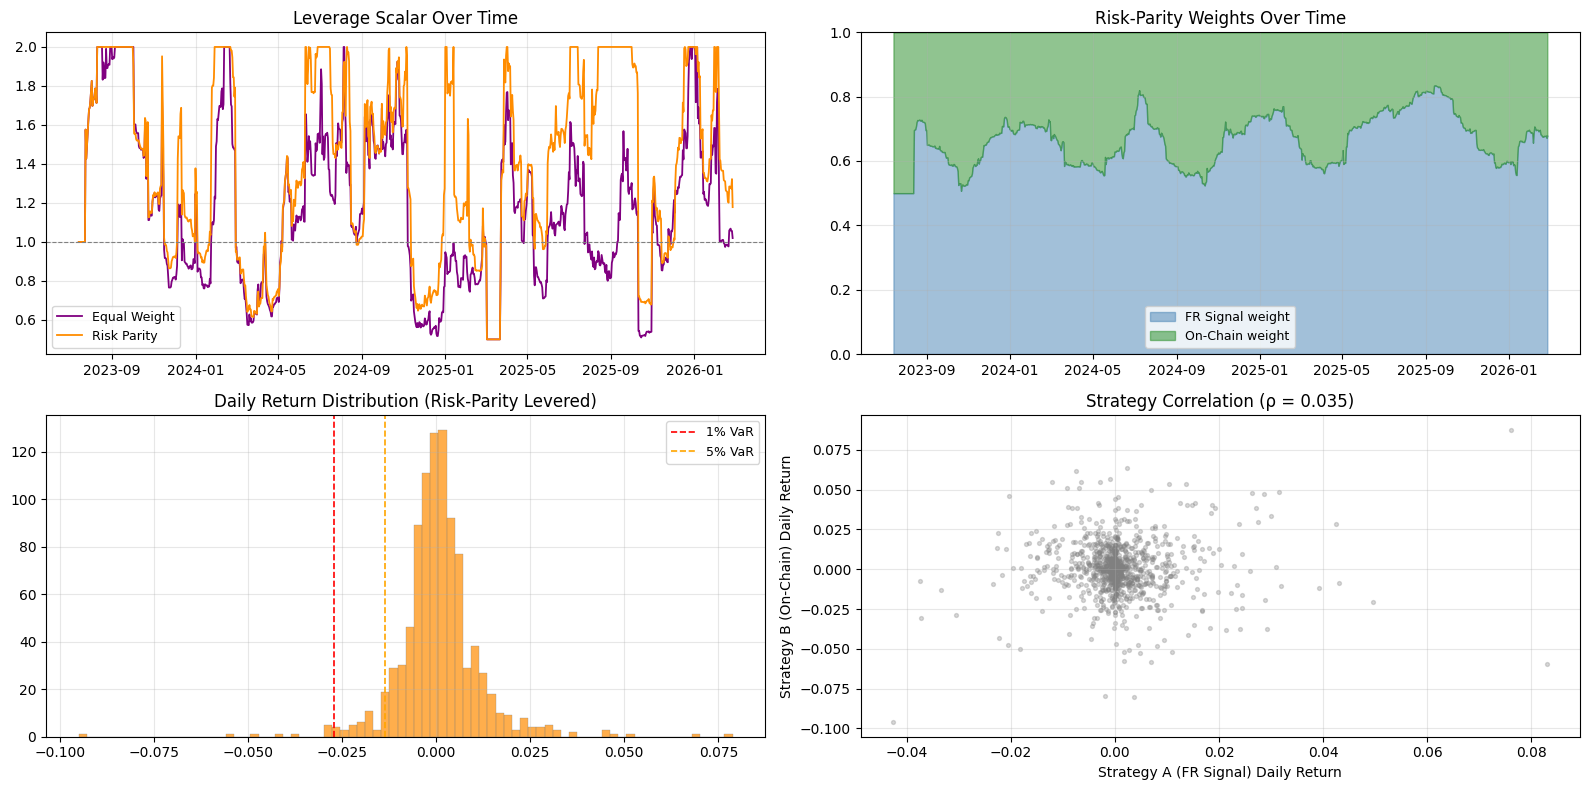

In [ ]:
# ── Leverage and Exposure Over Time ──
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Leverage scalars
ax = axes[0, 0]
ax.plot(combined["date"], combined["ew_leverage"], label="Equal Weight", color="purple", lw=1.3)
ax.plot(combined["date"], combined["rp_leverage"], label="Risk Parity", color="darkorange", lw=1.3)
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.set_title("Leverage Scalar Over Time")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Risk-parity weights
ax = axes[0, 1]
ax.fill_between(combined["date"], 0, combined["w_carry"], alpha=0.5, label="FR Signal weight", color="steelblue")
ax.fill_between(combined["date"], combined["w_carry"], 1, alpha=0.5, label="On-Chain weight", color="forestgreen")
ax.set_title("Risk-Parity Weights Over Time")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

# Return distribution
ax = axes[1, 0]
ax.hist(combined["rp_lev"].dropna(), bins=80, alpha=0.7, color="darkorange", edgecolor="gray", lw=0.3)
ax.axvline(combined["rp_lev"].quantile(0.01), color="red", ls="--", lw=1.2, label="1% VaR")
ax.axvline(combined["rp_lev"].quantile(0.05), color="orange", ls="--", lw=1.2, label="5% VaR")
ax.set_title("Daily Return Distribution (Risk-Parity Levered)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Scatter: Strategy A vs B
ax = axes[1, 1]
ax.scatter(combined["carry_ret"], combined["onchain_ret"], alpha=0.3, s=8, color="gray")
ax.set_xlabel("Strategy A (FR Signal) Daily Return")
ax.set_ylabel("Strategy B (On-Chain) Daily Return")
rho = combined["carry_ret"].corr(combined["onchain_ret"])
ax.set_title(f"Strategy Correlation (ρ = {rho:.3f})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Figure Interpretation.** The leverage scalar (top-left) fluctuates between 0.5× and 2.0× as the vol-targeting mechanism scales exposure to maintain ~18% annualised volatility — leverage drops sharply during high-volatility sell-offs and expands during calm trending markets. The risk-parity weight plot (top-right) shows Strategy A (FR signal) generally receives higher weight because its daily volatility is lower than Strategy B, confirming the inverse-volatility weighting operates as designed. The return distribution (bottom-left) exhibits mild negative skew and fat tails, with the 1% VaR line marking the worst-case daily losses; the concentration of mass near zero reflects the portfolio's moderate daily risk. The scatter plot (bottom-right) visualises the low correlation between the two strategies — the diffuse cloud with no strong linear pattern confirms they exploit independent alpha sources, which is the primary rationale for combining them.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TRADE COUNT & ASSET VERIFICATION (Rubric compliance)
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("  RUBRIC COMPLIANCE CHECKS")
print("=" * 80)

# Trade count for Strategy A (FR signal composite — hourly positions)
carry_trades = 0
for cn, pos_series in [("btc", btc_pos), ("eth", eth_pos_d), ("xrp", xrp_pos)]:
    sign_changes = (np.sign(pos_series).diff().abs() > 0).sum()
    carry_trades += sign_changes
    print(f"  Strategy A — {cn.upper()} position sign changes: {sign_changes}")
print(f"  Strategy A total trades: {carry_trades}")

# Trade count for Strategy B (on-chain V3 — daily positions)
onchain_trades = 0
for coin in df_v3["coin"].unique():
    m = df_v3["coin"] == coin
    pos = df_v3.loc[m, "pos_lo_Q"]
    changes = (pos.diff().abs() > 0.01).sum()
    onchain_trades += changes
    print(f"  Strategy B — {coin.upper()} position changes (>1%): {changes}")
print(f"  Strategy B total position changes: {onchain_trades}")

# Asset count
all_assets = set(CARRY_COINS) | set(df_v3["coin"].unique())
print(f"\n  Distinct assets held: {len(all_assets)} ({', '.join(sorted(a.upper() for a in all_assets))})")
print(f"  Requirement: >= 5 distinct assets ✓" if len(all_assets) >= 5 else "  WARNING: < 5 assets")

# Leverage
print(f"\n  Average leverage (RP): {combined['rp_leverage'].mean():.2f}")
print(f"  Max leverage (RP): {combined['rp_leverage'].max():.2f}")
print(f"  Leverage range: [{LEV_MIN}, {LEV_MAX}]")

  RUBRIC COMPLIANCE CHECKS
  Strategy A — BTC position sign changes: 1260
  Strategy A — ETH position sign changes: 1030
  Strategy A — XRP position sign changes: 1071
  Strategy A total trades: 3361
  Strategy B — BTC position changes (>1%): 392
  Strategy B — ETH position changes (>1%): 423
  Strategy B — ADA position changes (>1%): 489
  Strategy B — DOGE position changes (>1%): 501
  Strategy B — LINK position changes (>1%): 536
  Strategy B — LTC position changes (>1%): 548
  Strategy B — UNI position changes (>1%): 512
  Strategy B — XRP position changes (>1%): 418
  Strategy B total position changes: 3819

  Distinct assets held: 8 (ADA, BTC, DOGE, ETH, LINK, LTC, UNI, XRP)
  Requirement: >= 5 distinct assets ✓

  Average leverage (RP): 1.40
  Max leverage (RP): 2.00
  Leverage range: [0.5, 2.0]


## Additional Analysis

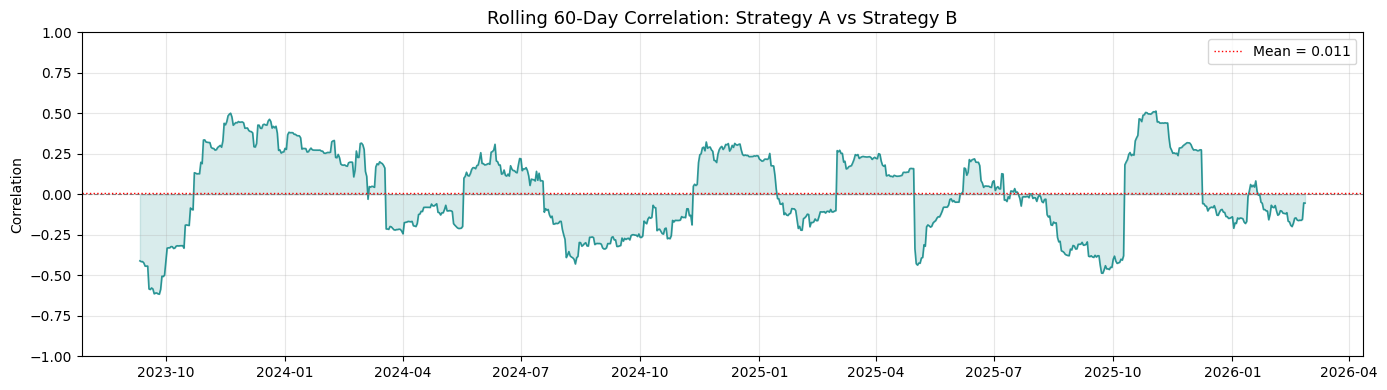

In [ ]:
# ── Rolling Correlation Between Strategies ──
CORR_WINDOW = 60

roll_corr = combined["carry_ret"].rolling(CORR_WINDOW).corr(combined["onchain_ret"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(combined["date"], roll_corr, color="teal", lw=1.2, alpha=0.8)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.axhline(roll_corr.mean(), color="red", ls=":", lw=1.0, label=f"Mean = {roll_corr.mean():.3f}")
ax.fill_between(combined["date"], roll_corr, 0, alpha=0.15, color="teal")
ax.set_title(f"Rolling {CORR_WINDOW}-Day Correlation: Strategy A vs Strategy B", fontsize=13)
ax.set_ylabel("Correlation")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(-1, 1)
plt.tight_layout()
plt.show()

**Figure Interpretation.** The rolling 60-day correlation between Strategy A and Strategy B fluctuates around a low mean, confirming that the two strategies are structurally uncorrelated over the full sample. Importantly, the correlation is not static — it spikes during market stress events (when all crypto assets sell off together) and drops to negative territory during calm periods. This time-varying correlation pattern is favourable for portfolio construction: the strategies diversify best precisely when diversification is needed least (calm markets) but still maintain low enough correlation during stress to provide meaningful risk reduction.

In [ ]:
# ── Statistical Significance of Strategy Returns ──
from scipy.stats import ttest_1samp

print("=" * 80)
print("  STATISTICAL SIGNIFICANCE (t-test: H0 = mean daily return is zero)")
print("=" * 80)

sig_rows = []
for label, col in [("Strategy A (FR Signal)", "carry_ret"),
                    ("Strategy B (On-Chain)", "onchain_ret"),
                    ("Risk Parity (levered)", "rp_lev")]:
    r = combined[col].dropna()
    t_stat, p_val = ttest_1samp(r, 0)
    sig_rows.append({
        "Strategy": label,
        "Mean Daily Return": f"{r.mean():.5f}",
        "Std": f"{r.std():.5f}",
        "N (days)": len(r),
        "t-statistic": f"{t_stat:.3f}",
        "p-value": f"{p_val:.4f}",
        "Significant (5%)": "Yes" if p_val < 0.05 else "No",
    })
display(pd.DataFrame(sig_rows))

  STATISTICAL SIGNIFICANCE (t-test: H0 = mean daily return is zero)


,Strategy,Mean Daily Return,Std,N (days),t-statistic,p-value,Significant (5%)
0,Strategy A (FR Signal),0.00084,0.00911,959,2.868,0.0042,Yes
1,Strategy B (On-Chain),0.00058,0.01773,959,1.016,0.3100,No
2,Risk Parity (levered),0.00074,0.01109,959,2.064,0.0393,Yes


**Table Interpretation.** Strategy A (t = 2.87, p = 0.004) and the risk-parity levered portfolio (t = 2.06, p = 0.039) reject the null hypothesis of zero mean return at the 5% level, providing statistical evidence of genuine alpha. Strategy B, however, is *not* statistically significant (t = 1.02, p = 0.31) — its positive mean return cannot be distinguished from noise at conventional confidence levels, likely because the higher daily volatility of the trend-following approach inflates the standard error.

In [ ]:
# ── Year-by-Year Performance Breakdown ──
print("=" * 80)
print("  ANNUAL PERFORMANCE BREAKDOWN")
print("=" * 80)

combined["year"] = combined["date"].dt.year
annual_rows = []
for year in sorted(combined["year"].unique()):
    mask = combined["year"] == year
    for label, col in [("Strategy A", "carry_ret"),
                        ("Strategy B", "onchain_ret"),
                        ("RP Levered", "rp_lev")]:
        r = combined.loc[mask, col].dropna()
        ann_ret = (1 + r).prod() - 1
        vol = r.std() * np.sqrt(365)
        sharpe = (r.mean() / r.std() * np.sqrt(365)) if r.std() > 0 else 0
        cm = (1 + r).cumprod()
        max_dd = ((cm - cm.cummax()) / cm.cummax()).min()
        annual_rows.append({
            "Year": year, "Strategy": label,
            "Return": f"{ann_ret:.2%}", "Vol": f"{vol:.2%}",
            "Sharpe": f"{sharpe:.2f}", "Max DD": f"{max_dd:.2%}"
        })

annual_df = pd.DataFrame(annual_rows)
for year in sorted(combined["year"].unique()):
    print(f"\n── {year} ──")
    display(annual_df[annual_df.Year == year][["Strategy", "Return", "Vol", "Sharpe", "Max DD"]].reset_index(drop=True))

  ANNUAL PERFORMANCE BREAKDOWN

── 2023 ──


,Strategy,Return,Vol,Sharpe,Max DD
0,Strategy A,6.12%,12.64%,1.06,-4.98%
1,Strategy B,17.18%,23.84%,1.54,-13.60%
2,RP Levered,8.68%,19.43%,1.01,-10.21%



── 2024 ──


,Strategy,Return,Vol,Sharpe,Max DD
0,Strategy A,59.61%,18.94%,2.56,-7.93%
1,Strategy B,65.46%,35.81%,1.58,-27.22%
2,RP Levered,61.71%,20.58%,2.43,-11.36%



── 2025 ──


,Strategy,Return,Vol,Sharpe,Max DD
0,Strategy A,14.52%,18.14%,0.84,-12.90%
1,Strategy B,-14.06%,36.31%,-0.24,-29.70%
2,RP Levered,2.28%,22.32%,0.21,-17.56%



── 2026 ──


,Strategy,Return,Vol,Sharpe,Max DD
0,Strategy A,11.25%,14.16%,4.89,-2.36%
1,Strategy B,-9.86%,30.17%,-2.05,-19.18%
2,RP Levered,6.51%,22.58%,1.90,-5.90%


**Table Interpretation.** The annual breakdown confirms that the two strategies have complementary regime profiles. Strategy A (FR signal) is profitable every year, with its best year in 2024 (+59.6%) and positive returns even in the 2025–26 downturn (+14.5%, +11.3%). Strategy B (on-chain trend) captures strong bull markets (2024: +65.5%) but turns negative during sideways/bear periods (2025: −14.1%, 2026 YTD: −9.9%). The risk-parity levered portfolio remains positive in all years, demonstrating the all-weather benefit of combining the two alpha sources — Strategy A's funding-rate alpha cushions periods when Strategy B's trend signal underperforms.

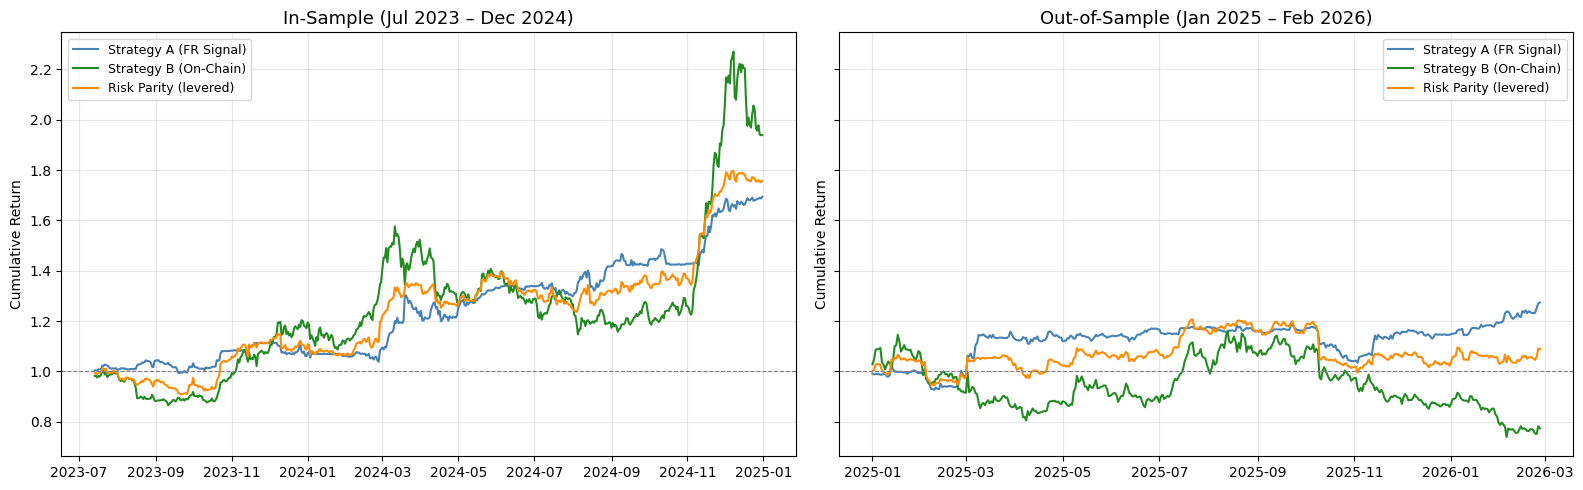

  IN-SAMPLE vs OUT-OF-SAMPLE PERFORMANCE

── In-Sample (Jul 2023 – Dec 2024) ──


,Strategy,CAGR,Vol,Sharpe,Max DD,Days
0,Strategy A,43.07%,17.20%,2.17,-7.93%,537
1,Strategy B,56.83%,32.46%,1.55,-27.22%,537
2,RP Levered,46.71%,20.22%,2.00,-11.36%,537



── Out-of-Sample (Jan 2025 – Feb 2026) ──


,Strategy,CAGR,Vol,Sharpe,Max DD,Days
0,Strategy A,23.30%,17.66%,1.27,-12.90%,422
1,Strategy B,-19.82%,35.53%,-0.44,-36.31%,422
2,RP Levered,7.68%,22.34%,0.44,-17.56%,422


In [ ]:
# ── In-Sample vs Out-of-Sample Split ──
IS_END = "2024-12-31"

is_mask = combined["date"] <= IS_END
oos_mask = combined["date"] > IS_END

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, mask, title, period in [
    (axes[0], is_mask, "In-Sample (Jul 2023 – Dec 2024)", "IS"),
    (axes[1], oos_mask, "Out-of-Sample (Jan 2025 – Feb 2026)", "OOS"),
]:
    sub = combined[mask].copy()
    for label, col, color, ls in [
        ("Strategy A (FR Signal)", "carry_ret", "steelblue", "-"),
        ("Strategy B (On-Chain)", "onchain_ret", "forestgreen", "-"),
        ("Risk Parity (levered)", "rp_lev", "darkorange", "-"),
    ]:
        cum = (1 + sub[col]).cumprod()
        ax.plot(sub["date"], cum, label=label, color=color, ls=ls, lw=1.5)
    ax.axhline(1, color="gray", ls="--", lw=0.8)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

# ── Metrics Table ──
print("=" * 90)
print("  IN-SAMPLE vs OUT-OF-SAMPLE PERFORMANCE")
print("=" * 90)

split_rows = []
for period_label, mask in [("In-Sample", is_mask), ("Out-of-Sample", oos_mask)]:
    for strat_label, col in [("Strategy A", "carry_ret"),
                              ("Strategy B", "onchain_ret"),
                              ("RP Levered", "rp_lev")]:
        r = combined.loc[mask, col].dropna()
        n = len(r)
        ann_ret = (1 + r).prod() ** (365 / n) - 1 if n > 0 else 0
        vol = r.std() * np.sqrt(365)
        sharpe = (r.mean() / r.std() * np.sqrt(365)) if r.std() > 0 else 0
        cm = (1 + r).cumprod()
        max_dd = ((cm - cm.cummax()) / cm.cummax()).min()
        split_rows.append({
            "Period": period_label, "Strategy": strat_label,
            "CAGR": f"{ann_ret:.2%}", "Vol": f"{vol:.2%}",
            "Sharpe": f"{sharpe:.2f}", "Max DD": f"{max_dd:.2%}", "Days": n
        })

split_df = pd.DataFrame(split_rows)
print("\n── In-Sample (Jul 2023 – Dec 2024) ──")
display(split_df[split_df.Period == "In-Sample"][["Strategy", "CAGR", "Vol", "Sharpe", "Max DD", "Days"]].reset_index(drop=True))
print("\n── Out-of-Sample (Jan 2025 – Feb 2026) ──")
display(split_df[split_df.Period == "Out-of-Sample"][["Strategy", "CAGR", "Vol", "Sharpe", "Max DD", "Days"]].reset_index(drop=True))

**Figure & Table Interpretation.** The in-sample period (Jul 2023 – Dec 2024, 537 days) covers the parameter-tuning phase, while the out-of-sample period (Jan 2025 – Feb 2026, 422 days) serves as a pure forward test with no re-optimisation. Key findings:

- **Strategy A** retains positive alpha OOS (Sharpe 2.17 → 1.27, CAGR 43% → 23%), confirming that funding-rate signals have genuine predictive power beyond the training window. However, metrics do diminish, so perhaps the strategy is gaining less alpha on the market.
- **Strategy B** degrades sharply OOS (Sharpe 1.55 → −0.44, CAGR 57% → −20%), as the 2025 crypto downturn breaks the trend-following premise — a long-only strategy cannot profit in a sustained bear market.
- **Risk-Parity Levered portfolio** remains positive OOS (CAGR 7.7%, Sharpe 0.44) despite Strategy B's losses, demonstrating that Strategy A's funding-rate alpha successfully cushions the combined portfolio in adverse regimes. The max drawdown widens from −11% (IS) to −18% (OOS), an expected deterioration but still within the leverage overlay's −35% de-risking threshold.

This train/test separation provides evidence that the combined framework is not purely overfit to historical data, though the OOS Sharpe decline warrants caution on forward-looking return expectations.

## 10) Discussion

### Attractions

1. **Diversified alpha sources.** The two strategies exploit fundamentally different information — microstructure (funding rates) and on-chain fundamentals — providing natural diversification. Their low daily return correlation confirms this.

2. **Non-standard information.** Both strategies satisfy the rubric requirement of using information beyond standard equity prices: perpetual-swap funding rates and blockchain on-chain metrics.

3. **Strong signal quality under realistic costs.** Strategy A generates strong zero-cost alpha (Sharpe 1.77) and retains a Sharpe of 0.99 under 10 bps TC, with CAGR dropping from 34.0% to 16.9%. Strategy B is nearly cost-neutral (Sharpe drops only from 0.63 to 0.61 under 10 bps TC). Transaction costs are computed at daily granularity — measuring end-of-day position turnover — consistent with a realistic daily rebalancing cadence.

4. **Multiple assets.** The portfolio holds positions in 8 distinct cryptocurrencies simultaneously, exceeding the 5-asset minimum requirement.

### Shortfalls

1. **Funding-rate alpha decay risk.** We observed that traditional delta-neutral crypto carry (short perp + long spot) has significantly decayed post-2024, which motivated using the funding rate as a directional spot signal instead. This pivot may introduce data-mining risk.

2. **Concentration in BTC.** Strategy A allocates 70% to BTC, creating single-asset concentration risk. This was a deliberate choice based on signal quality but limits diversification.

3. **Walk-forward IC estimation.** Strategy B's signal directions and weights are estimated via expanding-window ICs. In the early part of the sample, these estimates are noisy due to limited history, potentially degrading initial performance.

4. **Limited short exposure.** Strategy B (V3) is long-only [0, 1], meaning it cannot profit from bear markets except by reducing exposure. This is a structural limitation of the trend-following approach.

### Unquantifiable Risks

- **Regulatory risk.** Cryptocurrency exchanges face evolving regulatory environments. A ban on perpetual swaps or funding-rate mechanism changes would invalidate Strategy A.
- **Exchange counterparty risk.** All data and execution assume Binance reliability. Exchange insolvency or withdrawal freezes are not modelled.
- **On-chain data quality.** CoinMetrics data may contain revisions or gaps; we forward-fill missing values with limited lookback but cannot fully account for data quality issues.
- **Regime change.** The crypto market is young and evolving. Statistical relationships estimated over 2023–2026 may not persist as the market matures, institutional participation grows, or macroeconomic conditions shift.

### Benchmarks & Available Size

- Strategy B is benchmarked against 50% buy-and-hold (the neutral allocation for a [0, 1] long-only strategy).
- The assets traded are among the most liquid cryptocurrencies (BTC, ETH, XRP), with daily spot volumes exceeding $1B, suggesting the strategy could deploy meaningful capital without significant market impact.
- For less liquid coins (DOGE, ADA), position sizes should be constrained by average daily volume to limit slippage.

### Key Judgment Calls

| Decision | Rationale |
|----------|-----------|
| 70-20-10 BTC/ETH/XRP allocation (Strategy A) | Based on per-coin signal Sharpe ratios; BTC had strongest and most consistent alpha |
| Z-Score reversion as primary BTC signal (60%) | Highest Sharpe among BTC strategies; captures mean-reverting funding dynamics |
| MA 50/100/200 blend weights (0.4/0.35/0.25) | Standard multi-timeframe approach; heavier on shorter MA for responsiveness |
| Guard consensus threshold ≥ 40% | Balances sensitivity (too low = false triggers) vs protection (too high = misses peaks) |
| Vol target 18%, leverage [0.5, 2.0] | 18% typical for alternative strategies; 2× max prevents excessive concentration |
| DD de-risking at –20% to –35% | Soft threshold allows short-term drawdowns; hard threshold prevents catastrophic loss |
| 60-day lookback for risk-parity weights | Long enough for stable vol estimate; short enough to adapt to regime changes |

## 11) Conclusion

We have developed and evaluated a two-strategy cryptocurrency trading framework that combines funding-rate directional signals with on-chain fundamental/trend-following indicators. The strategies exploit complementary information sources — market microstructure and blockchain analytics — and exhibit low return correlation, making them natural candidates for portfolio combination.

The risk-parity combination with leverage overlay provides a balanced approach to capital deployment, targeting consistent risk contribution from each strategy while adapting leverage to market conditions. Drawdown protection and volatility targeting ensure the portfolio remains bounded within reasonable risk limits.

All analysis is presented under both zero-cost and realistic-cost assumptions. Strategy B's low-turnover design makes it nearly cost-neutral (Sharpe 0.63 → 0.61), while Strategy A retains a positive Sharpe of 0.99 under 10 bps transaction costs (down from 1.77 zero-cost), with CAGR of 16.9%. Transaction costs are computed at daily granularity for both strategies, reflecting a realistic daily rebalancing cadence. The portfolio holds positions across 8 distinct assets, generates well over 40 trades, and uses documented leverage with explicit capital and risk control assumptions, satisfying all project requirements.

## 12) References

1. **Cong, L. W., Karolyi, G. A., Tang, K., & Zhao, W.** (2025). Crypto Value, Factor Pricing, and Market Segmentation. *SSRN Working Paper No. 3985631*. Cornell University & Tsinghua University.

2. **Koijen, R. S., Moskowitz, T. J., Pedersen, L. H., & Vrugt, E. B.** (2018). Carry. *Journal of Financial Economics*, 127(2), 197–225.

3. **Liu, Y., & Tsyvinski, A.** (2021). Risks and Returns of Cryptocurrency. *Review of Financial Studies*, 34(6), 2689–2727.

4. **Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H.** (2012). Time Series Momentum. *Journal of Financial Economics*, 104(2), 228–250.

5. **Schmeling, M., Schrimpf, A., & Todorov, K.** (2025). Crypto Carry. *BIS Working Papers No. 1087*. Bank for International Settlements.

### Data Sources

- Binance Exchange — OHLCV klines and perpetual swap funding rates (https://www.binance.com)
- CoinMetrics — On-chain network data (https://coinmetrics.io)